## 垂直整合 benchmark， benchmark方法有 RunMOFA， RunMultigrate， RunMultiVI 和 RunSeurat V4
## 数据集 RNA+ATAC

In [1]:
import numpy as np
import pandas as pd
import scanpy as sc
import anndata as ad
import muon as mu
from scipy.io import mmread
from scipy.sparse import csr_matrix
import os, sys, time
from muon import MuData
import importlib
# sys.path.append(".")
# sys.path.append("./mofapy2/")
import mofapy2

## Garfield model

### 数据集 1_ShareSeq_Skin

In [1]:
import os
os.chdir('/data2/zhouwg_data/project/Garfield')
os.getcwd()

'/data2/zhouwg_data/project/Garfield'

In [2]:
# load packages
import os
import warnings
import Garfield as gf
import scanpy as sc
from mudata import MuData
warnings.simplefilter(action="ignore", category=FutureWarning)
warnings.simplefilter(action='ignore', category=UserWarning)

gf.__version__

/home/zhouweige/anaconda3/envs/env_gf_test/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


'0.3.8'

In [3]:
import pandas as pd
from scipy import io
from tqdm import tqdm

def check_file_exists(file_path):
    """Check if the file or directory exists and raise an error if not."""
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"The file or directory {file_path} does not exist.")

def read_rna_data(rna_dir):
    """Read RNA data including barcodes, features, and matrix from the specified directory."""
    rna_barcodes = pd.read_csv(f'{rna_dir}/barcodes.tsv', header=None, sep='\t', dtype=str)
    rna_features = pd.read_csv(f'{rna_dir}/features.tsv', header=None, sep='\t', dtype=str)
    rna_matrix = io.mmread(f'{rna_dir}/matrix.mtx').T.tocsr()

    rna = sc.AnnData(X=rna_matrix)
    rna.var['gene_symbols'] = rna_features.iloc[:, 0].values
    rna.obs['barcodes'] = rna_barcodes.iloc[:, 0].values
    rna.var_names = rna.var['gene_symbols']  # Set feature names
    rna.obs_names = rna.obs['barcodes']  # Set barcode names
    return rna

def read_atac_data(atac_dir):
    """Read ATAC data from the specified CSV file and return it as an AnnData object."""
    atac_barcodes = pd.read_csv(f'{atac_dir}/barcodes.tsv', header=None, sep='\t', dtype=str)
    atac_features = pd.read_csv(f'{atac_dir}/features.tsv', header=None, sep='\t', dtype=str)
    atac_matrix = io.mmread(f'{atac_dir}/matrix.mtx').T.tocsr()

    atac = sc.AnnData(X=atac_matrix)
    atac.var['gene_symbols'] = atac_features.iloc[:, 0].values
    atac.obs['barcodes'] = atac_barcodes.iloc[:, 0].values
    atac.var_names = atac.var['gene_symbols']  # Set feature names
    atac.obs_names = atac.obs['barcodes']  # Set barcode names
    return atac

def read_metadata(metadata_file):
    """Read metadata from a CSV file and return it as a DataFrame."""
    return pd.read_csv(metadata_file, index_col=0)

def read_multiomics_data(rna_dir, atac_dir, metadata_file):
    """
    Reads and processes RNA and ADT data, adding metadata to both.
    
    Parameters:
        rna_dir (str): Path to the directory containing RNA matrix, barcodes, and features.
        atac_file (str): Path to the CSV file containing ATAC data.
        metadata_file (str): Path to the CSV file containing metadata.
    
    Returns:
        dict: A dictionary with keys "rna" and "adt" containing the corresponding AnnData objects.
    """
    # Ensure all paths exist
    check_file_exists(rna_dir)
    check_file_exists(atac_dir)
    check_file_exists(metadata_file)

    # Use progress feedback to track steps
    with tqdm(total=3, desc="Reading multiomics data") as pbar:
        # Read RNA data
        rna = read_rna_data(rna_dir)
        pbar.update(1)

        # Read ADT data
        atac = read_atac_data(atac_dir)
        pbar.update(1)

        # Read metadata
        metadata = read_metadata(metadata_file)
        pbar.update(1)

    # Add metadata to RNA and ADT objects
    rna.obs = rna.obs.join(metadata, how="left")  # Ensure all metadata entries align
    atac.obs = atac.obs.join(metadata, how="left")

    return {"rna": rna, "atac": atac}

# Example usage with provided file paths
dataset = '1_ShareSeq_Skin' # 
rna_dir = f'/data2/zhouwg_data/project/Garfield_benchmark/datasets/MultiomicsBenchmark/Raw_data/RNA_ATAC/{dataset}/RNA'
atac_dir = f'/data2/zhouwg_data/project/Garfield_benchmark/datasets/MultiomicsBenchmark/Raw_data/RNA_ATAC/{dataset}/ATAC'
metadata_file = f'/data2/zhouwg_data/project/Garfield_benchmark/datasets/MultiomicsBenchmark/Raw_data/RNA_ATAC/{dataset}/meta_data.csv'

# Read the data
data = read_multiomics_data(rna_dir, atac_dir, metadata_file)

# Access RNA and ADT data separately
rna = data["rna"]
atac = data["atac"]
rna.layers['counts'] = rna.X.copy()
atac.layers['counts'] = atac.X.copy()

Reading multiomics data: 100%|██████████| 3/3 [00:15<00:00,  5.08s/it]


In [5]:
## load data
# rna.X = rna.X.toarray().astype(float)
# atac.X = atac.X.toarray().astype(float)
rna.var['feature_types'] = 'RNA'
atac.var['feature_types'] = 'ATAC'

# split each element for gene score calculation
split_data = atac.var_names.str.split('-', expand=True).to_frame(index=False)
split_data.index = atac.var_names
split_data.columns = ['chr', 'start', 'end']
atac.var[['chr', 'start', 'end']] = split_data

mdata = MuData({"rna": rna, "atac": atac})
mdata

MuData object with n_obs × n_vars = 34774 × 361596
  var:	'gene_symbols', 'feature_types'
  2 modalities
    rna:	34774 x 23296
      obs:	'barcodes', 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'RNA_snn_res.0.5', 'seurat_clusters', 'celltype', 'nCount_ATAC', 'nFeature_ATAC', 'RNA.weight', 'ATAC.weight', 'nCount_DORC', 'nFeature_DORC', 'DORC_snn_res.0.8', 'RNA_snn_res.0.8', 'ATAC_snn_res.0.8', 'DORC.weight', 'Default_wsnn_res.0.8', 'wsnn_res.0.8'
      var:	'gene_symbols', 'feature_types'
      layers:	'counts'
    atac:	34774 x 338300
      obs:	'barcodes', 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'RNA_snn_res.0.5', 'seurat_clusters', 'celltype', 'nCount_ATAC', 'nFeature_ATAC', 'RNA.weight', 'ATAC.weight', 'nCount_DORC', 'nFeature_DORC', 'DORC_snn_res.0.8', 'RNA_snn_res.0.8', 'ATAC_snn_res.0.8', 'DORC.weight', 'Default_wsnn_res.0.8', 'wsnn_res.0.8'
      var:	'gene_symbols', 'feature_types', 'chr', 'start', 'end'
      layers:	'counts'

In [6]:
# set workdir
workdir = '/data2/zhouwg_data/project/Garfield_benchmark/results/Vertical/RNA_ATAC/1_ShareSeq_Skin'
gf.settings.set_workdir(workdir)

### modify parameter
user_config = dict(
    ## Input options
    adata_list=mdata, 
    profile='multi-modal',   # if it is 'ATAC' or 'ADT', please adjust it.
    data_type='Paired',
    sub_data_type=['rna', 'atac'],
    sample_col=None,  # Specify columns for batch, only one batch, so set `None`
    weight=0.8,

    ## Preprocessing options
    genome='mm10',
    use_gene_weight=True,
    use_top_pcs=False,
    used_hvg=True,
    min_cells=3,
    min_features=0,
    keep_mt=False,
    target_sum=1e4,
    rna_n_top_features=3000,
    atac_n_top_features=10000, # if data belongs to 'ATAC', please specify it.
    n_components=50,
    n_neighbors=5,
    metric='euclidean',  
    svd_solver='arpack',
    # datasets
    used_pca_feat=True,
    adj_key='connectivities',
    
    # data split parameters
    edge_val_ratio=0.1,
    edge_test_ratio=0.,
    node_val_ratio=0.1,
    node_test_ratio=0.,

    ## Model options
    augment_type='svd',
    svd_q=5,
    use_FCencoder=False, 
    conv_type='GATv2Conv', # GAT or GATv2Conv or GCN
    gnn_layer=2,
    hidden_dims=[128, 128],
    bottle_neck_neurons=20,
    cluster_num=20,
    drop_feature_rate=0.2, 
    drop_edge_rate=0.2,
    num_heads=3,
    dropout=0.2,
    concat=True,
    used_edge_weight=True,
    used_DSBN=False,
    used_mmd=False,
    # data loader parameters
    num_neighbors=5,
    loaders_n_hops=2,
    edge_batch_size=4096,
    node_batch_size=128, # None
    # loss parameters
    include_edge_recon_loss=True,
    include_gene_expr_recon_loss=True,
    lambda_latent_contrastive_instanceloss=1.0,
    lambda_latent_contrastive_clusterloss=0.5,
    lambda_gene_expr_recon=10., # To make the model more focused on learning expression features, increase this parameter.
    lambda_edge_recon=100., # To make the model more focused on learning Adjacency graph features, increase this parameter.
    lambda_latent_adj_recon_loss=2.0,
    lambda_omics_recon_mmd_loss=3., # If the integration is not strong enough, increase it.
    # train parameters
    n_epochs_no_edge_recon=0,
    learning_rate=0.001,
    weight_decay=1e-05,
    gradient_clipping=5,
    # other parameters
    latent_key='garfield_latent',
    reload_best_model=True,
    use_early_stopping=True,
    early_stopping_kwargs=None,
    monitor=True,
    device_id=1,
    seed=2024,
    verbose=True
)
dict_config = gf.settings.set_gf_params(user_config)

Saving results in: /data2/zhouwg_data/project/Garfield_benchmark/results/Vertical/RNA_ATAC/1_ShareSeq_Skin


In [7]:
from Garfield.model import Garfield

# Initialize model
model = Garfield(dict_config)

--- DATA LOADING AND PREPROCESSING ---
Gene activity matrix has been calculated, loading cached adata_CG_atac object...
There are 18677 common genes in RNA and ATAC datasets
To start performing cell matching for adjacency matrix of the graph, please wait...
Finding initial pivots...
The first data is split into 6 batches, average batch size is 5795, and max batch size is 5799.
The second data is split into 6 batches, average batch size is 5795, and max batch size is 5799.
Batch to batch correspondence is:
  ['0<->0', '1<->1', '2<->2', '3<->3', '4<->4', '5<->5'].
Now at batch 0<->0...
Now at batch 1<->1...
Now at batch 2<->2...
Now at batch 3<->3...
Now at batch 4<->4...
Now at batch 5<->5...
Init_matching done!
Refining pivots...
Now at batch 0<->0...
Now at batch 1<->1...
Now at batch 2<->2...
Now at batch 3<->3...
Now at batch 4<->4...
Now at batch 5<->5...
Refined_matching done!
Filter_bad_matches on pivots matching...
Begin filtering...
24339/34774 pairs of matched cells remain aft

In [8]:
# Train model
model.train()


--- INITIALIZING TRAINER ---
Using GPU: 1
Number of training nodes: 31297
Number of validation nodes: 3477
Number of training edges: 392567
Number of validation edges: 43618
Edge batch size: 4096
Node batch size: 128

--- MODEL TRAINING ---
Epoch 1/100 |--------------------| 1.0% val_auroc_score: 0.7143; val_auprc_score: 0.7512; val_best_acc_score: 0.6737; val_best_f1_score: 0.6712; train_kl_reg_loss: 109.9338; train_edge_recon_loss: 111345.0774; train_gene_expr_recon_loss: 469584.6657; train_lambda_latent_adj_recon_loss: 2639.6381; train_lambda_latent_contrastive_instanceloss: 6.8880; train_lambda_latent_contrastive_clusterloss: 3.4579; train_global_loss: 583689.6530; train_optim_loss: 583689.6530; val_kl_reg_loss: 159.1713; val_edge_recon_loss: 104559.4126; val_gene_expr_recon_loss: 349404.7585; val_lambda_latent_adj_recon_loss: 3340.0613; val_lambda_latent_contrastive_instanceloss: 6.4685; val_lambda_latent_contrastive_clusterloss: 3.0419; val_global_loss: 457472.9205; val_optim_lo

In [9]:
# Compute latent neighbor graph
latent_key = 'garfield_latent'
sc.pp.neighbors(model.adata,
                use_rep=latent_key,
                key_added=latent_key)
# Compute UMAP embedding
sc.tl.umap(model.adata,
           neighbors_key=latent_key)

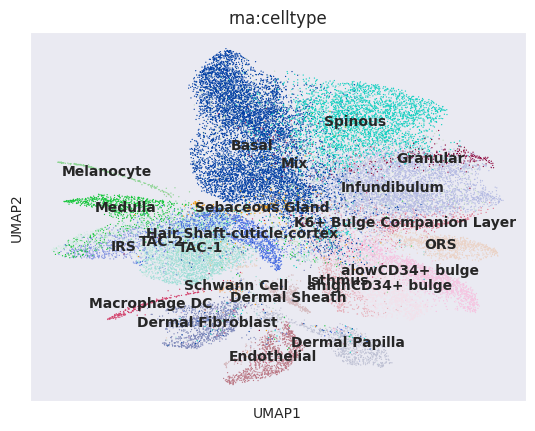

In [10]:
sc.pl.umap(model.adata, color=['rna:celltype'], wspace=0.15, show=True, legend_loc='on data')

In [11]:
# Compute latent Leiden clustering
latent_leiden_resolution = 1.0
latent_cluster_key = f"latent_leiden_{str(latent_leiden_resolution)}"
latent_key = "garfield_latent"

sc.tl.leiden(adata=model.adata,
             resolution=latent_leiden_resolution,
             key_added=latent_cluster_key,
             neighbors_key=latent_key)
len(model.adata.obs[latent_cluster_key].unique())

22

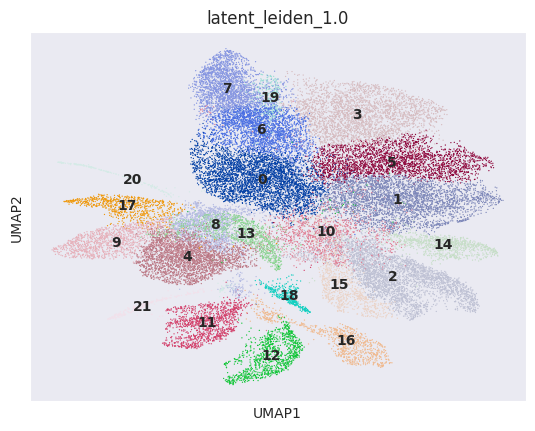

In [12]:
sc.pl.umap(model.adata, color=[latent_cluster_key], wspace=0.15, show=True, legend_loc='on data')

In [13]:
# Save trained model
model_folder_path = f"{workdir}/model"
os.makedirs(model_folder_path, exist_ok=True)

del model.adata.obsm['feat']
model.save(dir_path=model_folder_path,
           overwrite=True,
           save_adata=True,
           adata_file_name="adata_ref.h5ad")

Pickle failed with error: Can't pickle local object 'WeakSet.__init__.<locals>._remove', switching to dill...
Model saved successfully using dill at /data2/zhouwg_data/project/Garfield_benchmark/results/Vertical/RNA_ATAC/1_ShareSeq_Skin/model/attr.pkl


In [14]:
# 获取潜在表示
import numpy as np

latent = model.adata.obsm['garfield_latent'].copy()
np.savetxt(os.path.join(workdir, "Garfield.csv"), latent, delimiter=',')

### 数据集 2_brain_ShareSeq

In [1]:
import os
os.chdir('/data2/zhouwg_data/project/Garfield')
os.getcwd()

'/data2/zhouwg_data/project/Garfield'

In [2]:
# load packages
import os
import warnings
import Garfield as gf
import scanpy as sc
from mudata import MuData
warnings.simplefilter(action="ignore", category=FutureWarning)
warnings.simplefilter(action='ignore', category=UserWarning)

gf.__version__

/home/zhouweige/anaconda3/envs/env_gf_test/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


'0.3.8'

In [3]:
import pandas as pd
from scipy import io
from tqdm import tqdm

def check_file_exists(file_path):
    """Check if the file or directory exists and raise an error if not."""
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"The file or directory {file_path} does not exist.")

def read_rna_data(rna_dir):
    """Read RNA data including barcodes, features, and matrix from the specified directory."""
    rna_barcodes = pd.read_csv(f'{rna_dir}/barcodes.tsv', header=None, sep='\t', dtype=str)
    rna_features = pd.read_csv(f'{rna_dir}/features.tsv', header=None, sep='\t', dtype=str)
    rna_matrix = io.mmread(f'{rna_dir}/matrix.mtx').T.tocsr()

    rna = sc.AnnData(X=rna_matrix)
    rna.var['gene_symbols'] = rna_features.iloc[:, 0].values
    rna.obs['barcodes'] = rna_barcodes.iloc[:, 0].values
    rna.var_names = rna.var['gene_symbols']  # Set feature names
    rna.obs_names = rna.obs['barcodes']  # Set barcode names
    return rna

def read_atac_data(atac_dir):
    """Read ATAC data from the specified CSV file and return it as an AnnData object."""
    atac_barcodes = pd.read_csv(f'{atac_dir}/barcodes.tsv', header=None, sep='\t', dtype=str)
    atac_features = pd.read_csv(f'{atac_dir}/features.tsv', header=None, sep='\t', dtype=str)
    atac_matrix = io.mmread(f'{atac_dir}/matrix.mtx').T.tocsr()

    atac = sc.AnnData(X=atac_matrix)
    atac.var['gene_symbols'] = atac_features.iloc[:, 0].values
    atac.obs['barcodes'] = atac_barcodes.iloc[:, 0].values
    atac.var_names = atac.var['gene_symbols']  # Set feature names
    atac.obs_names = atac.obs['barcodes']  # Set barcode names
    return atac

def read_metadata(metadata_file):
    """Read metadata from a CSV file and return it as a DataFrame."""
    return pd.read_csv(metadata_file, index_col=0)

def read_multiomics_data(rna_dir, atac_dir, metadata_file):
    """
    Reads and processes RNA and ADT data, adding metadata to both.
    
    Parameters:
        rna_dir (str): Path to the directory containing RNA matrix, barcodes, and features.
        atac_file (str): Path to the CSV file containing ATAC data.
        metadata_file (str): Path to the CSV file containing metadata.
    
    Returns:
        dict: A dictionary with keys "rna" and "adt" containing the corresponding AnnData objects.
    """
    # Ensure all paths exist
    check_file_exists(rna_dir)
    check_file_exists(atac_dir)
    check_file_exists(metadata_file)

    # Use progress feedback to track steps
    with tqdm(total=3, desc="Reading multiomics data") as pbar:
        # Read RNA data
        rna = read_rna_data(rna_dir)
        pbar.update(1)

        # Read ADT data
        atac = read_atac_data(atac_dir)
        pbar.update(1)

        # Read metadata
        metadata = read_metadata(metadata_file)
        pbar.update(1)

    # Add metadata to RNA and ADT objects
    rna.obs = rna.obs.join(metadata, how="left")  # Ensure all metadata entries align
    atac.obs = atac.obs.join(metadata, how="left")

    return {"rna": rna, "atac": atac}

# Example usage with provided file paths
dataset = '2_brain_ShareSeq' # 1_ShareSeq_Skin
rna_dir = f'/data2/zhouwg_data/project/Garfield_benchmark/datasets/MultiomicsBenchmark/Raw_data/RNA_ATAC/{dataset}/RNA'
atac_dir = f'/data2/zhouwg_data/project/Garfield_benchmark/datasets/MultiomicsBenchmark/Raw_data/RNA_ATAC/{dataset}/ATAC'
metadata_file = f'/data2/zhouwg_data/project/Garfield_benchmark/datasets/MultiomicsBenchmark/Raw_data/RNA_ATAC/{dataset}/meta_data.csv'

# Read the data
data = read_multiomics_data(rna_dir, atac_dir, metadata_file)

# Access RNA and ADT data separately
rna = data["rna"]
atac = data["atac"]
rna.layers['counts'] = rna.X.copy()
atac.layers['counts'] = atac.X.copy()

Reading multiomics data: 100%|██████████| 3/3 [00:01<00:00,  2.14it/s]


In [4]:
## load data
# rna.X = rna.X.toarray().astype(float)
# atac.X = atac.X.toarray().astype(float)
rna.var['feature_types'] = 'RNA'
atac.var['feature_types'] = 'ATAC'

# split each element for gene score calculation
split_data = atac.var_names.str.split('-', expand=True).to_frame(index=False)
split_data.index = atac.var_names
split_data.columns = ['chr', 'start', 'end']
atac.var[['chr', 'start', 'end']] = split_data

mdata = MuData({"rna": rna, "atac": atac})
mdata

MuData object with n_obs × n_vars = 2344 × 319914
  var:	'gene_symbols', 'feature_types'
  2 modalities
    rna:	2344 x 21127
      obs:	'barcodes', 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'nCount_ATAC', 'nFeature_ATAC', 'blacklist_fraction', 'percent.mt', 'percent.ribo', 'RNA_snn_res.0.5', 'seurat_clusters', 'ATAC_snn_res.0.8', 'RNA.weight', 'ATAC.weight', 'wsnn_res.0.8', 'predicted.id', 'celltype'
      var:	'gene_symbols', 'feature_types'
      layers:	'counts'
    atac:	2344 x 298787
      obs:	'barcodes', 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'nCount_ATAC', 'nFeature_ATAC', 'blacklist_fraction', 'percent.mt', 'percent.ribo', 'RNA_snn_res.0.5', 'seurat_clusters', 'ATAC_snn_res.0.8', 'RNA.weight', 'ATAC.weight', 'wsnn_res.0.8', 'predicted.id', 'celltype'
      var:	'gene_symbols', 'feature_types', 'chr', 'start', 'end'
      layers:	'counts'

In [5]:
# set workdir
workdir = '/data2/zhouwg_data/project/Garfield_benchmark/results/Vertical/RNA_ATAC/2_brain_ShareSeq'
gf.settings.set_workdir(workdir)

### modify parameter
user_config = dict(
    ## Input options
    adata_list=mdata, 
    profile='multi-modal',   # if it is 'ATAC' or 'ADT', please adjust it.
    data_type='Paired',
    sub_data_type=['rna', 'atac'],
    sample_col=None,  # Specify columns for batch, only one batch, so set `None`
    weight=0.8,

    ## Preprocessing options
    genome='mm10',
    use_gene_weight=True,
    use_top_pcs=False,
    used_hvg=True,
    min_cells=3,
    min_features=0,
    keep_mt=False,
    target_sum=1e4,
    rna_n_top_features=3000,
    atac_n_top_features=10000, # if data belongs to 'ATAC', please specify it.
    n_components=50,
    n_neighbors=5,
    metric='euclidean',  
    svd_solver='arpack',
    # datasets
    used_pca_feat=True,
    adj_key='connectivities',
    
    # data split parameters
    edge_val_ratio=0.1,
    edge_test_ratio=0.,
    node_val_ratio=0.1,
    node_test_ratio=0.,

    ## Model options
    augment_type='svd',
    svd_q=5,
    use_FCencoder=False, 
    conv_type='GATv2Conv', # GAT or GATv2Conv or GCN
    gnn_layer=2,
    hidden_dims=[128, 128],
    bottle_neck_neurons=20,
    cluster_num=20,
    drop_feature_rate=0.2, 
    drop_edge_rate=0.2,
    num_heads=3,
    dropout=0.2,
    concat=True,
    used_edge_weight=True,
    used_DSBN=False,
    used_mmd=False,
    # data loader parameters
    num_neighbors=5,
    loaders_n_hops=2,
    edge_batch_size=4096,
    node_batch_size=128, # None
    # loss parameters
    include_edge_recon_loss=True,
    include_gene_expr_recon_loss=True,
    lambda_latent_contrastive_instanceloss=1.0,
    lambda_latent_contrastive_clusterloss=0.5,
    lambda_gene_expr_recon=10., # To make the model more focused on learning expression features, increase this parameter.
    lambda_edge_recon=100., # To make the model more focused on learning Adjacency graph features, increase this parameter.
    lambda_latent_adj_recon_loss=2.0,
    lambda_omics_recon_mmd_loss=3., # If the integration is not strong enough, increase it.
    # train parameters
    n_epochs_no_edge_recon=0,
    learning_rate=0.001,
    weight_decay=1e-05,
    gradient_clipping=5,
    # other parameters
    latent_key='garfield_latent',
    reload_best_model=True,
    use_early_stopping=True,
    early_stopping_kwargs=None,
    monitor=True,
    device_id=1,
    seed=2024,
    verbose=True
)
dict_config = gf.settings.set_gf_params(user_config)

Saving results in: /data2/zhouwg_data/project/Garfield_benchmark/results/Vertical/RNA_ATAC/2_brain_ShareSeq


In [6]:
from Garfield.model import Garfield

# Initialize model
model = Garfield(dict_config)

--- DATA LOADING AND PREPROCESSING ---
Gene activity matrix has been calculated, loading cached adata_CG_atac object...
There are 16067 common genes in RNA and ATAC datasets
To start performing cell matching for adjacency matrix of the graph, please wait...
Finding initial pivots...
The first data is split into 1 batches, average batch size is 2344, and max batch size is 2344.
The second data is split into 1 batches, average batch size is 2344, and max batch size is 2344.
Batch to batch correspondence is:
  ['0<->0'].
Now at batch 0<->0...
Init_matching done!
Refining pivots...
Now at batch 0<->0...
Refined_matching done!
Filter_bad_matches on pivots matching...
Begin filtering...
1641/2344 pairs of matched cells remain after the filtering.
Fitting CCA on pivots...
Scoring matched pairs...
Propagating matching...
Now at batch 0<->0...
Done!
Filter_bad_matches on propagated matching...
Begin filtering...
1406/1406 pairs of matched cells remain after the filtering.
Fitting CCA on pivots.

In [7]:
# Train model
model.train()


--- INITIALIZING TRAINER ---
Using GPU: 1
Number of training nodes: 2110
Number of validation nodes: 234
Number of training edges: 16283
Number of validation edges: 1809
Edge batch size: 4096
Node batch size: 128

--- MODEL TRAINING ---
Epoch 1/100 |--------------------| 1.0% val_auroc_score: 0.6978; val_auprc_score: 0.7139; val_best_acc_score: 0.6481; val_best_f1_score: 0.6768; train_kl_reg_loss: 1372.8251; train_edge_recon_loss: 113760.7715; train_gene_expr_recon_loss: 1419898.2188; train_lambda_latent_adj_recon_loss: 1617.3687; train_lambda_latent_contrastive_instanceloss: 7.1100; train_lambda_latent_contrastive_clusterloss: 3.7678; train_global_loss: 1536660.0625; train_optim_loss: 1536660.0625; val_kl_reg_loss: 30.9693; val_edge_recon_loss: 52959.6680; val_gene_expr_recon_loss: 1168985.0000; val_lambda_latent_adj_recon_loss: 980.6953; val_lambda_latent_contrastive_instanceloss: 6.8649; val_lambda_latent_contrastive_clusterloss: 3.7600; val_global_loss: 1222967.0000; val_optim_los

In [8]:
# Compute latent neighbor graph
latent_key = 'garfield_latent'
sc.pp.neighbors(model.adata,
                use_rep=latent_key,
                key_added=latent_key)
# Compute UMAP embedding
sc.tl.umap(model.adata,
           neighbors_key=latent_key)

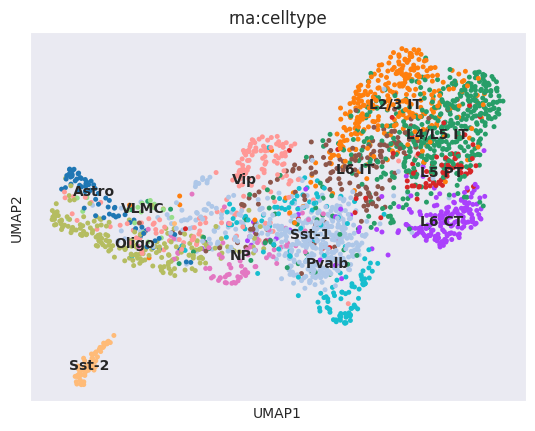

In [9]:
sc.pl.umap(model.adata, color=['rna:celltype'], wspace=0.15, show=True, legend_loc='on data')

In [10]:
# Compute latent Leiden clustering
latent_leiden_resolution = 1.0
latent_cluster_key = f"latent_leiden_{str(latent_leiden_resolution)}"
latent_key = "garfield_latent"

sc.tl.leiden(adata=model.adata,
             resolution=latent_leiden_resolution,
             key_added=latent_cluster_key,
             neighbors_key=latent_key)
len(model.adata.obs[latent_cluster_key].unique())

14

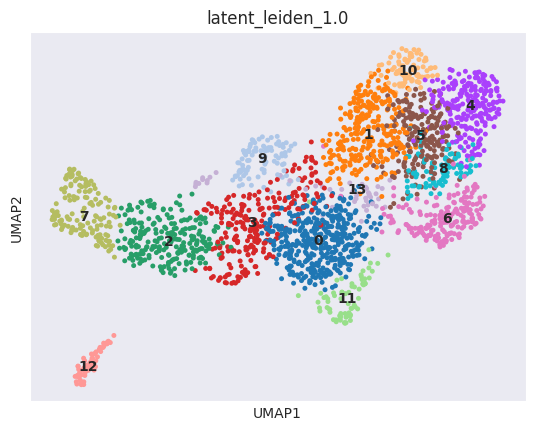

In [11]:
sc.pl.umap(model.adata, color=[latent_cluster_key], wspace=0.15, show=True, legend_loc='on data')

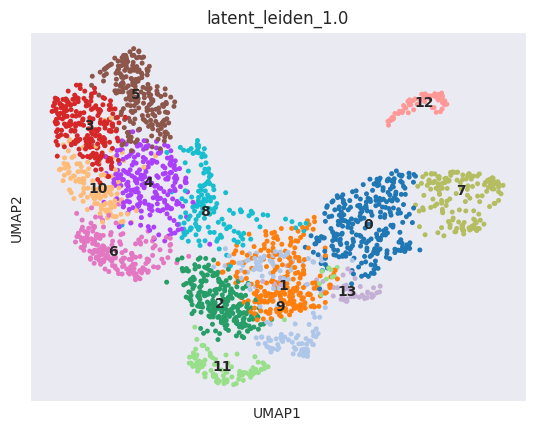

In [11]:
sc.pl.umap(model.adata, color=[latent_cluster_key], wspace=0.15, show=True, legend_loc='on data')

In [12]:
# Save trained model
model_folder_path = f"{workdir}/model"
os.makedirs(model_folder_path, exist_ok=True)

del model.adata.obsm['feat']
model.save(dir_path=model_folder_path,
           overwrite=True,
           save_adata=True,
           adata_file_name="adata_ref.h5ad")

Pickle failed with error: Can't pickle local object 'WeakSet.__init__.<locals>._remove', switching to dill...
Model saved successfully using dill at /data2/zhouwg_data/project/Garfield_benchmark/results/Vertical/RNA_ATAC/2_brain_ShareSeq/model/attr.pkl


In [13]:
# 获取潜在表示
import numpy as np

latent = model.adata.obsm['garfield_latent'].copy()
np.savetxt(os.path.join(workdir, "Garfield.csv"), latent, delimiter=',')

### 数据集 3_brain_SNARE with Garfield

In [1]:
import os
os.chdir('/data2/zhouwg_data/project/Garfield')
os.getcwd()

'/data2/zhouwg_data/project/Garfield'

In [2]:
# load packages
import os
import warnings
import Garfield as gf
import scanpy as sc
from mudata import MuData
warnings.simplefilter(action="ignore", category=FutureWarning)
warnings.simplefilter(action='ignore', category=UserWarning)

gf.__version__

/home/zhouweige/anaconda3/envs/env_gf_test/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


'0.3.8'

In [11]:
import pandas as pd
from scipy import io
from tqdm import tqdm

def check_file_exists(file_path):
    """Check if the file or directory exists and raise an error if not."""
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"The file or directory {file_path} does not exist.")

def read_rna_data(rna_dir):
    """Read RNA data including barcodes, features, and matrix from the specified directory."""
    rna_barcodes = pd.read_csv(f'{rna_dir}/barcodes.tsv', header=None, sep='\t', dtype=str)
    rna_features = pd.read_csv(f'{rna_dir}/features.tsv', header=None, sep='\t', dtype=str)
    rna_matrix = io.mmread(f'{rna_dir}/matrix.mtx').T.tocsr()

    rna = sc.AnnData(X=rna_matrix)
    rna.var['gene_symbols'] = rna_features.iloc[:, 0].values
    rna.obs['barcodes'] = rna_barcodes.iloc[:, 0].values
    rna.var_names = rna.var['gene_symbols']  # Set feature names
    rna.obs_names = rna.obs['barcodes']  # Set barcode names
    return rna

def read_atac_data(atac_dir):
    """Read ATAC data from the specified CSV file and return it as an AnnData object."""
    atac_barcodes = pd.read_csv(f'{atac_dir}/barcodes.tsv', header=None, sep='\t', dtype=str)
    atac_features = pd.read_csv(f'{atac_dir}/features.tsv', header=None, sep='\t', dtype=str)
    atac_matrix = io.mmread(f'{atac_dir}/matrix.mtx').T.tocsr()

    atac = sc.AnnData(X=atac_matrix)
    atac.var['gene_symbols'] = atac_features.iloc[:, 0].values
    atac.obs['barcodes'] = atac_barcodes.iloc[:, 0].values
    atac.var_names = atac.var['gene_symbols']  # Set feature names
    atac.obs_names = atac.obs['barcodes']  # Set barcode names
    return atac

def read_metadata(metadata_file):
    """Read metadata from a CSV file and return it as a DataFrame."""
    return pd.read_csv(metadata_file, index_col=0)

def read_multiomics_data(rna_dir, atac_dir, metadata_file):
    """
    Reads and processes RNA and ADT data, adding metadata to both.

    Parameters:
        rna_dir (str): Path to the directory containing RNA matrix, barcodes, and features.
        atac_file (str): Path to the CSV file containing ATAC data.
        metadata_file (str): Path to the CSV file containing metadata.

    Returns:
        dict: A dictionary with keys "rna" and "adt" containing the corresponding AnnData objects.
    """
    # Ensure all paths exist
    check_file_exists(rna_dir)
    check_file_exists(atac_dir)
    check_file_exists(metadata_file)

    # Use progress feedback to track steps
    with tqdm(total=3, desc="Reading multiomics data") as pbar:
        # Read RNA data
        rna = read_rna_data(rna_dir)
        pbar.update(1)

        # Read ADT data
        atac = read_atac_data(atac_dir)
        pbar.update(1)

        # Read metadata
        metadata = read_metadata(metadata_file)
        pbar.update(1)

    # Add metadata to RNA and ADT objects
    rna.obs = rna.obs.join(metadata, how="left")  # Ensure all metadata entries align
    atac.obs = atac.obs.join(metadata, how="left")

    return {"rna": rna, "atac": atac}

# Example usage with provided file paths
dataset = '3_brain_SNARE' #
rna_dir = f'/data2/zhouwg_data/project/Garfield_benchmark/datasets/MultiomicsBenchmark/Raw_data/RNA_ATAC/{dataset}/RNA'
atac_dir = f'/data2/zhouwg_data/project/Garfield_benchmark/datasets/MultiomicsBenchmark/Raw_data/RNA_ATAC/{dataset}/ATAC'
metadata_file = f'/data2/zhouwg_data/project/Garfield_benchmark/datasets/MultiomicsBenchmark/Raw_data/RNA_ATAC/{dataset}/meta_data.csv'

# Read the data
data = read_multiomics_data(rna_dir, atac_dir, metadata_file)

# Access RNA and ADT data separately
rna = data["rna"]
atac = data["atac"]
rna.layers['counts'] = rna.X.copy()
atac.layers['counts'] = atac.X.copy()

Reading multiomics data: 100%|██████████| 3/3 [00:03<00:00,  1.10s/it]


In [12]:
## load data
# rna.X = rna.X.toarray().astype(float)
# atac.X = atac.X.toarray().astype(float)
rna.var['feature_types'] = 'RNA'
atac.var['feature_types'] = 'ATAC'

# split each element for gene score calculation
split_data = atac.var_names.str.split('-', expand=True).to_frame(index=False)
split_data.index = atac.var_names
split_data.columns = ['chr', 'start', 'end']
atac.var[['chr', 'start', 'end']] = split_data

mdata = MuData({"rna": rna, "atac": atac})
mdata

MuData object with n_obs × n_vars = 8055 × 263441
  var:	'gene_symbols', 'feature_types'
  2 modalities
    rna:	8055 x 33160
      obs:	'barcodes', 'RNA_snn_res.0.5', 'celltype'
      var:	'gene_symbols', 'feature_types'
      layers:	'counts'
    atac:	8055 x 230281
      obs:	'barcodes', 'RNA_snn_res.0.5', 'celltype'
      var:	'gene_symbols', 'feature_types', 'chr', 'start', 'end'
      layers:	'counts'

In [13]:
# 定义genome类型
human_datasets = ["5_human_brain_10x", "6_pbmc_granulocyte_sorted_10x", "7_human_pbmc_10x",
                  "8_pbmc_unsorted_10k", "9_pbmc_unsorted_3k"]
mouse_datasets = ["1_ShareSeq_Skin", "2_brain_ShareSeq", "3_brain_SNARE","4_brain_ISSAAC_seq","10_GSE201402_down"]

if dataset in human_datasets:
    genome = 'hg38'
else:
    genome = 'mm10'

In [14]:
# set workdir
workdir = f'/data2/zhouwg_data/project/Garfield_benchmark/results/Vertical/RNA_ATAC/{dataset}'
gf.settings.set_workdir(workdir)

### modify parameter
user_config = dict(
    ## Input options
    adata_list=mdata,
    profile='multi-modal',   # if it is 'ATAC' or 'ADT', please adjust it.
    data_type='Paired',
    sub_data_type=['rna', 'atac'],
    sample_col=None,  # Specify columns for batch, only one batch, so set `None`
    weight=0.8,

    ## Preprocessing options
    genome=genome,
    use_gene_weight=True,
    use_top_pcs=False,
    used_hvg=True,
    min_cells=3,
    min_features=0,
    keep_mt=False,
    target_sum=1e4,
    rna_n_top_features=3000,
    atac_n_top_features=10000, # if data belongs to 'ATAC', please specify it.
    n_components=50,
    n_neighbors=5,
    metric='euclidean',
    svd_solver='arpack',
    # datasets
    used_pca_feat=True,
    adj_key='connectivities',

    # data split parameters
    edge_val_ratio=0.1,
    edge_test_ratio=0.,
    node_val_ratio=0.1,
    node_test_ratio=0.,

    ## Model options
    augment_type='svd',
    svd_q=5,
    use_FCencoder=False,
    conv_type='GATv2Conv', # GAT or GATv2Conv or GCN
    gnn_layer=2,
    hidden_dims=[128, 128],
    bottle_neck_neurons=20,
    cluster_num=20,
    drop_feature_rate=0.2,
    drop_edge_rate=0.2,
    num_heads=3,
    dropout=0.2,
    concat=True,
    used_edge_weight=True,
    used_DSBN=False,
    used_mmd=False,
    # data loader parameters
    num_neighbors=5,
    loaders_n_hops=2,
    edge_batch_size=4096,
    node_batch_size=128, # None
    # loss parameters
    include_edge_recon_loss=True,
    include_gene_expr_recon_loss=True,
    lambda_latent_contrastive_instanceloss=1.0,
    lambda_latent_contrastive_clusterloss=0.5,
    lambda_gene_expr_recon=10., # To make the model more focused on learning expression features, increase this parameter.
    lambda_edge_recon=100., # To make the model more focused on learning Adjacency graph features, increase this parameter.
    lambda_latent_adj_recon_loss=2.0,
    lambda_omics_recon_mmd_loss=3., # If the integration is not strong enough, increase it.
    # train parameters
    n_epochs_no_edge_recon=0,
    learning_rate=0.001,
    weight_decay=1e-05,
    gradient_clipping=5,
    # other parameters
    latent_key='garfield_latent',
    reload_best_model=True,
    use_early_stopping=True,
    early_stopping_kwargs=None,
    monitor=True,
    device_id=1,
    seed=2024,
    verbose=True
)
dict_config = gf.settings.set_gf_params(user_config)

Saving results in: /data2/zhouwg_data/project/Garfield_benchmark/results/Vertical/RNA_ATAC/3_brain_SNARE


In [15]:
from Garfield.model import Garfield

# Initialize model
model = Garfield(dict_config)

--- DATA LOADING AND PREPROCESSING ---
Gene activity matrix has been calculated, loading cached adata_CG_atac object...
There are 18643 common genes in RNA and ATAC datasets
To start performing cell matching for adjacency matrix of the graph, please wait...
Finding initial pivots...
The first data is split into 1 batches, average batch size is 8055, and max batch size is 8055.
The second data is split into 1 batches, average batch size is 8055, and max batch size is 8055.
Batch to batch correspondence is:
  ['0<->0'].
Now at batch 0<->0...
Init_matching done!
Refining pivots...
Now at batch 0<->0...
Refined_matching done!
Filter_bad_matches on pivots matching...
Begin filtering...
5638/8055 pairs of matched cells remain after the filtering.
Fitting CCA on pivots...
Scoring matched pairs...
Propagating matching...
Now at batch 0<->0...
Done!
Filter_bad_matches on propagated matching...
Begin filtering...
4834/4834 pairs of matched cells remain after the filtering.
Fitting CCA on pivots.

In [16]:
# Train model
model.train()


--- INITIALIZING TRAINER ---
Using GPU: 1
Number of training nodes: 7249
Number of validation nodes: 806
Number of training edges: 57907
Number of validation edges: 6434
Edge batch size: 4096
Node batch size: 128

--- MODEL TRAINING ---
Epoch 1/100 |--------------------| 1.0% val_auroc_score: 0.7434; val_auprc_score: 0.7393; val_best_acc_score: 0.6829; val_best_f1_score: 0.7068; train_kl_reg_loss: 20.2430; train_edge_recon_loss: 107430.8677; train_gene_expr_recon_loss: 497439.4562; train_lambda_latent_adj_recon_loss: 928.1717; train_lambda_latent_contrastive_instanceloss: 7.2046; train_lambda_latent_contrastive_clusterloss: 3.7324; train_global_loss: 605829.6833; train_optim_loss: 605829.6833; val_kl_reg_loss: 26.8664; val_edge_recon_loss: 85877.0566; val_gene_expr_recon_loss: 470242.7500; val_lambda_latent_adj_recon_loss: 623.6981; val_lambda_latent_contrastive_instanceloss: 6.8232; val_lambda_latent_contrastive_clusterloss: 3.6361; val_global_loss: 556780.8750; val_optim_loss: 55678

In [17]:
# Compute latent neighbor graph
latent_key = 'garfield_latent'
sc.pp.neighbors(model.adata,
                use_rep=latent_key,
                key_added=latent_key)
# Compute UMAP embedding
sc.tl.umap(model.adata,
           neighbors_key=latent_key)

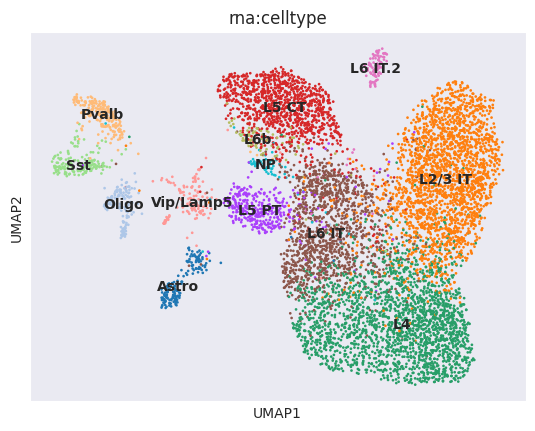

In [18]:
sc.pl.umap(model.adata, color=['rna:celltype'], wspace=0.15, show=True, legend_loc='on data')

In [19]:
# Compute latent Leiden clustering
latent_leiden_resolution = 1.0
latent_cluster_key = f"latent_leiden_{str(latent_leiden_resolution)}"
latent_key = "garfield_latent"

sc.tl.leiden(adata=model.adata,
             resolution=latent_leiden_resolution,
             key_added=latent_cluster_key,
             neighbors_key=latent_key)
len(model.adata.obs[latent_cluster_key].unique())

17

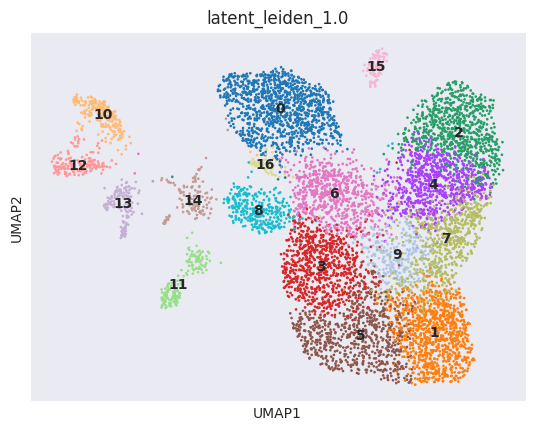

In [20]:
sc.pl.umap(model.adata, color=[latent_cluster_key], wspace=0.15, show=True, legend_loc='on data')

In [21]:
# Save trained model
model_folder_path = f"{workdir}/model"
os.makedirs(model_folder_path, exist_ok=True)

del model.adata.obsm['feat']
model.save(dir_path=model_folder_path,
           overwrite=True,
           save_adata=True,
           adata_file_name="adata_ref.h5ad")

Pickle failed with error: Can't pickle local object 'WeakSet.__init__.<locals>._remove', switching to dill...
Model saved successfully using dill at /data2/zhouwg_data/project/Garfield_benchmark/results/Vertical/RNA_ATAC/3_brain_SNARE/model/attr.pkl


In [22]:
# 获取潜在表示
import numpy as np

latent = model.adata.obsm['garfield_latent'].copy()
np.savetxt(os.path.join(workdir, "Garfield_new.csv"), latent, delimiter=',')

### 数据集 4_brain_ISSAAC_seq with Garfield

In [1]:
import os
os.chdir('/data2/zhouwg_data/project/Garfield')
os.getcwd()

'/data2/zhouwg_data/project/Garfield'

In [2]:
# load packages
import os
import warnings
import Garfield as gf
import scanpy as sc
from mudata import MuData
warnings.simplefilter(action="ignore", category=FutureWarning)
warnings.simplefilter(action='ignore', category=UserWarning)

gf.__version__

/home/zhouweige/anaconda3/envs/env_gf_test/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


'0.3.8'

In [3]:
import pandas as pd
from scipy import io
from tqdm import tqdm

def check_file_exists(file_path):
    """Check if the file or directory exists and raise an error if not."""
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"The file or directory {file_path} does not exist.")

def read_rna_data(rna_dir):
    """Read RNA data including barcodes, features, and matrix from the specified directory."""
    rna_barcodes = pd.read_csv(f'{rna_dir}/barcodes.tsv', header=None, sep='\t', dtype=str)
    rna_features = pd.read_csv(f'{rna_dir}/features.tsv', header=None, sep='\t', dtype=str)
    rna_matrix = io.mmread(f'{rna_dir}/matrix.mtx').T.tocsr()

    rna = sc.AnnData(X=rna_matrix)
    rna.var['gene_symbols'] = rna_features.iloc[:, 0].values
    rna.obs['barcodes'] = rna_barcodes.iloc[:, 0].values
    rna.var_names = rna.var['gene_symbols']  # Set feature names
    rna.obs_names = rna.obs['barcodes']  # Set barcode names
    return rna

def read_atac_data(atac_dir):
    """Read ATAC data from the specified CSV file and return it as an AnnData object."""
    atac_barcodes = pd.read_csv(f'{atac_dir}/barcodes.tsv', header=None, sep='\t', dtype=str)
    atac_features = pd.read_csv(f'{atac_dir}/features.tsv', header=None, sep='\t', dtype=str)
    atac_matrix = io.mmread(f'{atac_dir}/matrix.mtx').T.tocsr()

    atac = sc.AnnData(X=atac_matrix)
    atac.var['gene_symbols'] = atac_features.iloc[:, 0].values
    atac.obs['barcodes'] = atac_barcodes.iloc[:, 0].values
    atac.var_names = atac.var['gene_symbols']  # Set feature names
    atac.obs_names = atac.obs['barcodes']  # Set barcode names
    return atac

def read_metadata(metadata_file):
    """Read metadata from a CSV file and return it as a DataFrame."""
    return pd.read_csv(metadata_file, index_col=0)

def read_multiomics_data(rna_dir, atac_dir, metadata_file):
    """
    Reads and processes RNA and ADT data, adding metadata to both.

    Parameters:
        rna_dir (str): Path to the directory containing RNA matrix, barcodes, and features.
        atac_file (str): Path to the CSV file containing ATAC data.
        metadata_file (str): Path to the CSV file containing metadata.

    Returns:
        dict: A dictionary with keys "rna" and "adt" containing the corresponding AnnData objects.
    """
    # Ensure all paths exist
    check_file_exists(rna_dir)
    check_file_exists(atac_dir)
    check_file_exists(metadata_file)

    # Use progress feedback to track steps
    with tqdm(total=3, desc="Reading multiomics data") as pbar:
        # Read RNA data
        rna = read_rna_data(rna_dir)
        pbar.update(1)

        # Read ADT data
        atac = read_atac_data(atac_dir)
        pbar.update(1)

        # Read metadata
        metadata = read_metadata(metadata_file)
        pbar.update(1)

    # Add metadata to RNA and ADT objects
    rna.obs = rna.obs.join(metadata, how="left")  # Ensure all metadata entries align
    atac.obs = atac.obs.join(metadata, how="left")

    return {"rna": rna, "atac": atac}

# Example usage with provided file paths
dataset = '4_brain_ISSAAC_seq' #
rna_dir = f'/data2/zhouwg_data/project/Garfield_benchmark/datasets/MultiomicsBenchmark/Raw_data/RNA_ATAC/{dataset}/RNA'
atac_dir = f'/data2/zhouwg_data/project/Garfield_benchmark/datasets/MultiomicsBenchmark/Raw_data/RNA_ATAC/{dataset}/ATAC'
metadata_file = f'/data2/zhouwg_data/project/Garfield_benchmark/datasets/MultiomicsBenchmark/Raw_data/RNA_ATAC/{dataset}/meta_data.csv'

# Read the data
data = read_multiomics_data(rna_dir, atac_dir, metadata_file)

# Access RNA and ADT data separately
rna = data["rna"]
atac = data["atac"]
rna.layers['counts'] = rna.X.copy()
atac.layers['counts'] = atac.X.copy()

Reading multiomics data: 100%|██████████| 3/3 [00:08<00:00,  2.71s/it]


In [4]:
## load data
# rna.X = rna.X.toarray().astype(float)
# atac.X = atac.X.toarray().astype(float)
rna.var['feature_types'] = 'RNA'
atac.var['feature_types'] = 'ATAC'

# split each element for gene score calculation
split_data = atac.var_names.str.split('-', expand=True).to_frame(index=False)
split_data.index = atac.var_names
split_data.columns = ['chr', 'start', 'end']
atac.var[['chr', 'start', 'end']] = split_data

mdata = MuData({"rna": rna, "atac": atac})
mdata

MuData object with n_obs × n_vars = 10361 × 197472
  var:	'gene_symbols', 'feature_types'
  2 modalities
    rna:	10361 x 32285
      obs:	'barcodes', 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'nCount_ATAC', 'nFeature_ATAC', 'TSS.enrichment', 'TSS.percentile', 'nucleosome_signal', 'nucleosome_percentile', 'fragments', 'FRiP', 'blacklist_fraction', 'percent.mt', 'percent.ribo', 'Group', 'RNA_snn_res.1', 'seurat_clusters', 'ATAC_snn_res.1', 'celltype', 'prediction.score.Vip', 'prediction.score.Lamp5', 'prediction.score.Sst', 'prediction.score.Sncg', 'prediction.score.Serpinf1', 'prediction.score.Pvalb', 'prediction.score.Endo', 'prediction.score.Peri', 'prediction.score.L6.CT', 'prediction.score.L6b', 'prediction.score.L6.IT', 'prediction.score.L2.3.IT', 'prediction.score.CR', 'prediction.score.L5.PT', 'prediction.score.NP', 'prediction.score.L4', 'prediction.score.L5.IT', 'prediction.score.Oligo', 'prediction.score.Meis2', 'prediction.score.Astro', 'prediction.score.Macrophage', 'prediction.score.VLMC', 'prediction.score.SMC', 'prediction.score.max', 'RNA_UMAP1', 'RNA_UMAP2', 'ATAC_UMAP1', 'ATAC_UMAP2', 'batch', 'RNA_Cluster', 'ATAC_Cluster', 'Annotation', 'RNA_Cluster_relabel', 'RNA_Cluster_colour', 'ATAC_Cluster_colour', 'nCount_aRNA', 'nFeature_aRNA', 'aRNA_snn_res.0.8', 'ATAC_snn_res.0.8', 'RNA_snn_res.0.5'
      var:	'gene_symbols', 'feature_types'
      layers:	'counts'
    atac:	10361 x 165187
      obs:	'barcodes', 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'nCount_ATAC', 'nFeature_ATAC', 'TSS.enrichment', 'TSS.percentile', 'nucleosome_signal', 'nucleosome_percentile', 'fragments', 'FRiP', 'blacklist_fraction', 'percent.mt', 'percent.ribo', 'Group', 'RNA_snn_res.1', 'seurat_clusters', 'ATAC_snn_res.1', 'celltype', 'prediction.score.Vip', 'prediction.score.Lamp5', 'prediction.score.Sst', 'prediction.score.Sncg', 'prediction.score.Serpinf1', 'prediction.score.Pvalb', 'prediction.score.Endo', 'prediction.score.Peri', 'prediction.score.L6.CT', 'prediction.score.L6b', 'prediction.score.L6.IT', 'prediction.score.L2.3.IT', 'prediction.score.CR', 'prediction.score.L5.PT', 'prediction.score.NP', 'prediction.score.L4', 'prediction.score.L5.IT', 'prediction.score.Oligo', 'prediction.score.Meis2', 'prediction.score.Astro', 'prediction.score.Macrophage', 'prediction.score.VLMC', 'prediction.score.SMC', 'prediction.score.max', 'RNA_UMAP1', 'RNA_UMAP2', 'ATAC_UMAP1', 'ATAC_UMAP2', 'batch', 'RNA_Cluster', 'ATAC_Cluster', 'Annotation', 'RNA_Cluster_relabel', 'RNA_Cluster_colour', 'ATAC_Cluster_colour', 'nCount_aRNA', 'nFeature_aRNA', 'aRNA_snn_res.0.8', 'ATAC_snn_res.0.8', 'RNA_snn_res.0.5'
      var:	'gene_symbols', 'feature_types', 'chr', 'start', 'end'
      layers:	'counts'

In [5]:
# 定义genome类型
human_datasets = ["5_human_brain_10x", "6_pbmc_granulocyte_sorted_10x", "7_human_pbmc_10x",
                  "8_pbmc_unsorted_10k", "9_pbmc_unsorted_3k"]
mouse_datasets = ["1_ShareSeq_Skin", "2_brain_ShareSeq", "3_brain_SNARE","4_brain_ISSAAC_seq","10_GSE201402_down"]

if dataset in human_datasets:
    genome = 'hg38'
else:
    genome = 'mm10'

In [6]:
# set workdir
workdir = f'/data2/zhouwg_data/project/Garfield_benchmark/results/Vertical/RNA_ATAC/{dataset}'
gf.settings.set_workdir(workdir)

### modify parameter
user_config = dict(
    ## Input options
    adata_list=mdata,
    profile='multi-modal',   # if it is 'ATAC' or 'ADT', please adjust it.
    data_type='Paired',
    sub_data_type=['rna', 'atac'],
    sample_col=None,  # Specify columns for batch, only one batch, so set `None`
    weight=0.8,

    ## Preprocessing options
    genome=genome,
    use_gene_weight=True,
    use_top_pcs=False,
    used_hvg=True,
    min_cells=3,
    min_features=0,
    keep_mt=False,
    target_sum=1e4,
    rna_n_top_features=3000,
    atac_n_top_features=10000, # if data belongs to 'ATAC', please specify it.
    n_components=50,
    n_neighbors=5,
    metric='euclidean',
    svd_solver='arpack',
    # datasets
    used_pca_feat=True,
    adj_key='connectivities',

    # data split parameters
    edge_val_ratio=0.1,
    edge_test_ratio=0.,
    node_val_ratio=0.1,
    node_test_ratio=0.,

    ## Model options
    augment_type='svd',
    svd_q=5,
    use_FCencoder=False,
    conv_type='GATv2Conv', # GAT or GATv2Conv or GCN
    gnn_layer=2,
    hidden_dims=[128, 128],
    bottle_neck_neurons=20,
    cluster_num=20,
    drop_feature_rate=0.2,
    drop_edge_rate=0.2,
    num_heads=3,
    dropout=0.2,
    concat=True,
    used_edge_weight=True,
    used_DSBN=False,
    used_mmd=False,
    # data loader parameters
    num_neighbors=5,
    loaders_n_hops=2,
    edge_batch_size=4096,
    node_batch_size=128, # None
    # loss parameters
    include_edge_recon_loss=True,
    include_gene_expr_recon_loss=True,
    lambda_latent_contrastive_instanceloss=1.0,
    lambda_latent_contrastive_clusterloss=0.5,
    lambda_gene_expr_recon=10., # To make the model more focused on learning expression features, increase this parameter.
    lambda_edge_recon=50., # To make the model more focused on learning Adjacency graph features, increase this parameter.
    lambda_latent_adj_recon_loss=2.0,
    lambda_omics_recon_mmd_loss=3., # If the integration is not strong enough, increase it.
    # train parameters
    n_epochs_no_edge_recon=0,
    learning_rate=0.001,
    weight_decay=1e-05,
    gradient_clipping=5,
    # other parameters
    latent_key='garfield_latent',
    reload_best_model=True,
    use_early_stopping=True,
    early_stopping_kwargs=None,
    monitor=True,
    device_id=1,
    seed=2024,
    verbose=True
)
dict_config = gf.settings.set_gf_params(user_config)

Saving results in: /data2/zhouwg_data/project/Garfield_benchmark/results/Vertical/RNA_ATAC/4_brain_ISSAAC_seq


In [7]:
from Garfield.model import Garfield

# Initialize model
model = Garfield(dict_config)

--- DATA LOADING AND PREPROCESSING ---
Gene activity matrix has been calculated, loading cached adata_CG_atac object...
There are 19155 common genes in RNA and ATAC datasets
To start performing cell matching for adjacency matrix of the graph, please wait...
Finding initial pivots...
The first data is split into 2 batches, average batch size is 5180, and max batch size is 5181.
The second data is split into 2 batches, average batch size is 5180, and max batch size is 5181.
Batch to batch correspondence is:
  ['0<->0', '1<->1'].
Now at batch 0<->0...
Now at batch 1<->1...
Init_matching done!
Refining pivots...
Now at batch 0<->0...
Now at batch 1<->1...
Refined_matching done!
Filter_bad_matches on pivots matching...
Begin filtering...
7253/10361 pairs of matched cells remain after the filtering.
Fitting CCA on pivots...
Scoring matched pairs...
Propagating matching...
Now at batch 0<->0...
Now at batch 1<->1...
Done!
Filter_bad_matches on propagated matching...
Begin filtering...
26938/2

In [8]:
# Train model
model.train()


--- INITIALIZING TRAINER ---
Using GPU: 1
Number of training nodes: 9325
Number of validation nodes: 1036
Number of training edges: 76383
Number of validation edges: 8486
Edge batch size: 4096
Node batch size: 128

--- MODEL TRAINING ---
Epoch 1/100 |--------------------| 1.0% val_auroc_score: 0.8605; val_auprc_score: 0.8750; val_best_acc_score: 0.8073; val_best_f1_score: 0.8003; train_kl_reg_loss: 183.6360; train_edge_recon_loss: 55477.5956; train_gene_expr_recon_loss: 1228224.8849; train_lambda_latent_adj_recon_loss: 2286.8290; train_lambda_latent_contrastive_instanceloss: 7.1697; train_lambda_latent_contrastive_clusterloss: 3.7201; train_global_loss: 1286183.8750; train_optim_loss: 1286183.8750; val_kl_reg_loss: 93.5226; val_edge_recon_loss: 39290.1426; val_gene_expr_recon_loss: 899513.3750; val_lambda_latent_adj_recon_loss: 3339.0646; val_lambda_latent_contrastive_instanceloss: 6.8718; val_lambda_latent_contrastive_clusterloss: 3.6729; val_global_loss: 942246.6667; val_optim_loss:

In [9]:
# Compute latent neighbor graph
latent_key = 'garfield_latent'
sc.pp.neighbors(model.adata,
                use_rep=latent_key,
                key_added=latent_key)
# Compute UMAP embedding
sc.tl.umap(model.adata,
           neighbors_key=latent_key)

In [10]:
model.adata

AnnData object with n_obs × n_vars = 10361 × 13000
    obs: 'rna:barcodes', 'rna:orig.ident', 'rna:nCount_RNA', 'rna:nFeature_RNA', 'rna:nCount_ATAC', 'rna:nFeature_ATAC', 'rna:TSS.enrichment', 'rna:TSS.percentile', 'rna:nucleosome_signal', 'rna:nucleosome_percentile', 'rna:fragments', 'rna:FRiP', 'rna:blacklist_fraction', 'rna:percent.mt', 'rna:percent.ribo', 'rna:Group', 'rna:RNA_snn_res.1', 'rna:seurat_clusters', 'rna:ATAC_snn_res.1', 'rna:celltype', 'rna:prediction.score.Vip', 'rna:prediction.score.Lamp5', 'rna:prediction.score.Sst', 'rna:prediction.score.Sncg', 'rna:prediction.score.Serpinf1', 'rna:prediction.score.Pvalb', 'rna:prediction.score.Endo', 'rna:prediction.score.Peri', 'rna:prediction.score.L6.CT', 'rna:prediction.score.L6b', 'rna:prediction.score.L6.IT', 'rna:prediction.score.L2.3.IT', 'rna:prediction.score.CR', 'rna:prediction.score.L5.PT', 'rna:prediction.score.NP', 'rna:prediction.score.L4', 'rna:prediction.score.L5.IT', 'rna:prediction.score.Oligo', 'rna:prediction

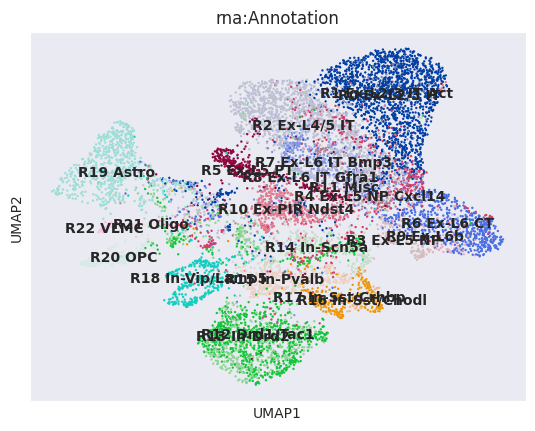

In [11]:
sc.pl.umap(model.adata, color=['rna:Annotation'], wspace=0.15, show=True, legend_loc='on data')

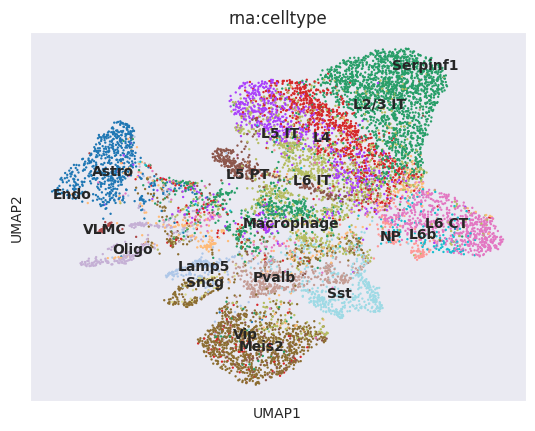

In [12]:
sc.pl.umap(model.adata, color=['rna:celltype'], wspace=0.15, show=True, legend_loc='on data')

In [13]:
# Compute latent Leiden clustering
latent_leiden_resolution = 1.0
latent_cluster_key = f"latent_leiden_{str(latent_leiden_resolution)}"
latent_key = "garfield_latent"

sc.tl.leiden(adata=model.adata,
             resolution=latent_leiden_resolution,
             key_added=latent_cluster_key,
             neighbors_key=latent_key)
len(model.adata.obs[latent_cluster_key].unique())

22

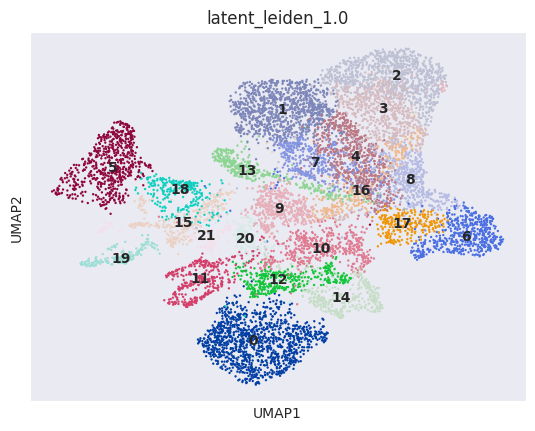

In [14]:
sc.pl.umap(model.adata, color=[latent_cluster_key], wspace=0.15, show=True, legend_loc='on data')

In [15]:
# Save trained model
model_folder_path = f"{workdir}/model"
os.makedirs(model_folder_path, exist_ok=True)

del model.adata.obsm['feat']
model.save(dir_path=model_folder_path,
           overwrite=True,
           save_adata=True,
           adata_file_name="adata_ref.h5ad")

Pickle failed with error: Can't pickle local object 'WeakSet.__init__.<locals>._remove', switching to dill...
Model saved successfully using dill at /data2/zhouwg_data/project/Garfield_benchmark/results/Vertical/RNA_ATAC/4_brain_ISSAAC_seq/model/attr.pkl


In [16]:
# 获取潜在表示
import numpy as np

latent = model.adata.obsm['garfield_latent'].copy()
np.savetxt(os.path.join(workdir, "Garfield.csv"), latent, delimiter=',')

### 数据集 7_human_pbmc_10x

In [19]:
import os
os.chdir('/data2/zhouwg_data/project/Garfield')
os.getcwd()

'/data2/zhouwg_data/project/Garfield'

In [20]:
# load packages
import os
import warnings
import Garfield as gf
import scanpy as sc
from mudata import MuData
warnings.simplefilter(action="ignore", category=FutureWarning)
warnings.simplefilter(action='ignore', category=UserWarning)

gf.__version__

'0.3.8'

In [21]:
import pandas as pd
from scipy import io
from tqdm import tqdm

def check_file_exists(file_path):
    """Check if the file or directory exists and raise an error if not."""
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"The file or directory {file_path} does not exist.")

def read_rna_data(rna_dir):
    """Read RNA data including barcodes, features, and matrix from the specified directory."""
    rna_barcodes = pd.read_csv(f'{rna_dir}/barcodes.tsv', header=None, sep='\t', dtype=str)
    rna_features = pd.read_csv(f'{rna_dir}/features.tsv', header=None, sep='\t', dtype=str)
    rna_matrix = io.mmread(f'{rna_dir}/matrix.mtx').T.tocsr()

    rna = sc.AnnData(X=rna_matrix)
    rna.var['gene_symbols'] = rna_features.iloc[:, 0].values
    rna.obs['barcodes'] = rna_barcodes.iloc[:, 0].values
    rna.var_names = rna.var['gene_symbols']  # Set feature names
    rna.obs_names = rna.obs['barcodes']  # Set barcode names
    return rna

def read_atac_data(atac_dir):
    """Read ATAC data from the specified CSV file and return it as an AnnData object."""
    atac_barcodes = pd.read_csv(f'{atac_dir}/barcodes.tsv', header=None, sep='\t', dtype=str)
    atac_features = pd.read_csv(f'{atac_dir}/features.tsv', header=None, sep='\t', dtype=str)
    atac_matrix = io.mmread(f'{atac_dir}/matrix.mtx').T.tocsr()

    atac = sc.AnnData(X=atac_matrix)
    atac.var['gene_symbols'] = atac_features.iloc[:, 0].values
    atac.obs['barcodes'] = atac_barcodes.iloc[:, 0].values
    atac.var_names = atac.var['gene_symbols']  # Set feature names
    atac.obs_names = atac.obs['barcodes']  # Set barcode names
    return atac

def read_metadata(metadata_file):
    """Read metadata from a CSV file and return it as a DataFrame."""
    return pd.read_csv(metadata_file, index_col=0)

def read_multiomics_data(rna_dir, atac_dir, metadata_file):
    """
    Reads and processes RNA and ADT data, adding metadata to both.

    Parameters:
        rna_dir (str): Path to the directory containing RNA matrix, barcodes, and features.
        atac_file (str): Path to the CSV file containing ATAC data.
        metadata_file (str): Path to the CSV file containing metadata.

    Returns:
        dict: A dictionary with keys "rna" and "adt" containing the corresponding AnnData objects.
    """
    # Ensure all paths exist
    check_file_exists(rna_dir)
    check_file_exists(atac_dir)
    check_file_exists(metadata_file)

    # Use progress feedback to track steps
    with tqdm(total=3, desc="Reading multiomics data") as pbar:
        # Read RNA data
        rna = read_rna_data(rna_dir)
        pbar.update(1)

        # Read ADT data
        atac = read_atac_data(atac_dir)
        pbar.update(1)

        # Read metadata
        metadata = read_metadata(metadata_file)
        pbar.update(1)

    # Add metadata to RNA and ADT objects
    rna.obs = rna.obs.join(metadata, how="left")  # Ensure all metadata entries align
    atac.obs = atac.obs.join(metadata, how="left")

    return {"rna": rna, "atac": atac}

# Example usage with provided file paths
dataset = '7_human_pbmc_10x' #
rna_dir = f'/data2/zhouwg_data/project/Garfield_benchmark/datasets/MultiomicsBenchmark/Raw_data/RNA_ATAC/{dataset}/RNA'
atac_dir = f'/data2/zhouwg_data/project/Garfield_benchmark/datasets/MultiomicsBenchmark/Raw_data/RNA_ATAC/{dataset}/ATAC'
metadata_file = f'/data2/zhouwg_data/project/Garfield_benchmark/datasets/MultiomicsBenchmark/Raw_data/RNA_ATAC/{dataset}/meta_data.csv'

# Read the data
data = read_multiomics_data(rna_dir, atac_dir, metadata_file)

# Access RNA and ADT data separately
rna = data["rna"].copy()
atac = data["atac"].copy()
rna.layers['counts'] = rna.X.copy()
atac.layers['counts'] = atac.X.copy()

Reading multiomics data: 100%|██████████| 3/3 [00:02<00:00,  1.27it/s]


In [22]:
## load data
# rna.X = rna.X.toarray().astype(float)
# atac.X = atac.X.toarray().astype(float)
rna.var['feature_types'] = 'RNA'
atac.var['feature_types'] = 'ATAC'

# split each element for gene score calculation
split_data = atac.var_names.str.split('-', expand=True).to_frame(index=False)
split_data.index = atac.var_names
split_data.columns = ['chr', 'start', 'end']
atac.var[['chr', 'start', 'end']] = split_data

mdata = MuData({"rna": rna, "atac": atac})
mdata

MuData object with n_obs × n_vars = 2592 × 132061
  var:	'gene_symbols', 'feature_types'
  2 modalities
    rna:	2592 x 36601
      obs:	'barcodes', 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'nCount_ATAC', 'nFeature_ATAC', 'TSS.enrichment', 'TSS.percentile', 'nucleosome_signal', 'nucleosome_percentile', 'fragments', 'FRiP', 'blacklist_fraction', 'percent.mt', 'percent.ribo', 'ATAC_snn_res.0.8', 'seurat_clusters', 'nCount_SCT', 'nFeature_SCT', 'SCT_snn_res.0.5', 'predicted.id', 'SCT_snn_res.0.8', 'celltype', 'SCT.weight', 'ATAC.weight', 'wsnn_res.0.8'
      var:	'gene_symbols', 'feature_types'
      layers:	'counts'
    atac:	2592 x 95460
      obs:	'barcodes', 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'nCount_ATAC', 'nFeature_ATAC', 'TSS.enrichment', 'TSS.percentile', 'nucleosome_signal', 'nucleosome_percentile', 'fragments', 'FRiP', 'blacklist_fraction', 'percent.mt', 'percent.ribo', 'ATAC_snn_res.0.8', 'seurat_clusters', 'nCount_SCT', 'nFeature_SCT', 'SCT_snn_res.0.5', 'predicted.id', 'SCT_snn_res.0.8', 'celltype', 'SCT.weight', 'ATAC.weight', 'wsnn_res.0.8'
      var:	'gene_symbols', 'feature_types', 'chr', 'start', 'end'
      layers:	'counts'

In [23]:
# 定义genome类型
human_datasets = ["5_human_brain_10x", "6_pbmc_granulocyte_sorted_10x", "7_human_pbmc_10x",
                  "8_pbmc_unsorted_10k", "9_pbmc_unsorted_3k"]
mouse_datasets = ["1_ShareSeq_Skin", "2_brain_ShareSeq", "3_brain_SNARE","4_brain_ISSAAC_seq","10_GSE201402_down"]

if dataset in human_datasets:
    genome = 'hg38'
else:
    genome = 'mm10'

In [24]:
# set workdir
workdir = f'/data2/zhouwg_data/project/Garfield_benchmark/results/Vertical/RNA_ATAC/{dataset}'
gf.settings.set_workdir(workdir)

### modify parameter
user_config = dict(
    ## Input options
    adata_list=mdata,
    profile='multi-modal',   # if it is 'ATAC' or 'ADT', please adjust it.
    data_type='Paired',
    sub_data_type=['rna', 'atac'],
    sample_col=None,  # Specify columns for batch, only one batch, so set `None`
    weight=0.8,

    ## Preprocessing options
    genome=genome,
    use_gene_weight=True,
    use_top_pcs=False,
    used_hvg=True,
    min_cells=3,
    min_features=0,
    keep_mt=False,
    target_sum=1e4,
    rna_n_top_features=3000,
    atac_n_top_features=10000, # if data belongs to 'ATAC', please specify it.
    n_components=50,
    n_neighbors=5,
    metric='euclidean',
    svd_solver='arpack',
    # datasets
    used_pca_feat=True,
    adj_key='connectivities',

    # data split parameters
    edge_val_ratio=0.1,
    edge_test_ratio=0.,
    node_val_ratio=0.1,
    node_test_ratio=0.,

    ## Model options
    augment_type='svd',
    svd_q=5,
    use_FCencoder=False,
    conv_type='GATv2Conv', # GAT or GATv2Conv or GCN
    gnn_layer=2,
    hidden_dims=[128, 128],
    bottle_neck_neurons=20,
    cluster_num=20,
    drop_feature_rate=0.2,
    drop_edge_rate=0.2,
    num_heads=3,
    dropout=0.2,
    concat=True,
    used_edge_weight=True,
    used_DSBN=False,
    used_mmd=False,
    # data loader parameters
    num_neighbors=5,
    loaders_n_hops=2,
    edge_batch_size=4096,
    node_batch_size=128, # None
    # loss parameters
    include_edge_recon_loss=True,
    include_gene_expr_recon_loss=True,
    lambda_latent_contrastive_instanceloss=1.0,
    lambda_latent_contrastive_clusterloss=0.5,
    lambda_gene_expr_recon=1., # To make the model more focused on learning expression features, increase this parameter.
    lambda_edge_recon=50., # To make the model more focused on learning Adjacency graph features, increase this parameter.
    lambda_latent_adj_recon_loss=2.0,
    lambda_omics_recon_mmd_loss=3., # If the integration is not strong enough, increase it.
    # train parameters
    n_epochs_no_edge_recon=0,
    learning_rate=0.001,
    weight_decay=1e-05,
    gradient_clipping=5,
    # other parameters
    latent_key='garfield_latent',
    reload_best_model=True,
    use_early_stopping=True,
    early_stopping_kwargs=None,
    monitor=True,
    device_id=1,
    seed=2024,
    verbose=True
)
dict_config = gf.settings.set_gf_params(user_config)

Saving results in: /data2/zhouwg_data/project/Garfield_benchmark/results/Vertical/RNA_ATAC/7_human_pbmc_10x


In [25]:
from Garfield.model import Garfield

# Initialize model
model = Garfield(dict_config)

--- DATA LOADING AND PREPROCESSING ---
Gene activity matrix has been calculated, loading cached adata_CG_atac object...
There are 16301 common genes in RNA and ATAC datasets
To start performing cell matching for adjacency matrix of the graph, please wait...
Finding initial pivots...
The first data is split into 1 batches, average batch size is 2592, and max batch size is 2592.
The second data is split into 1 batches, average batch size is 2592, and max batch size is 2592.
Batch to batch correspondence is:
  ['0<->0'].
Now at batch 0<->0...
Init_matching done!
Refining pivots...
Now at batch 0<->0...
Refined_matching done!
Filter_bad_matches on pivots matching...
Begin filtering...
1814/2592 pairs of matched cells remain after the filtering.
Fitting CCA on pivots...
Scoring matched pairs...
Propagating matching...
Now at batch 0<->0...
Done!
Filter_bad_matches on propagated matching...
Begin filtering...
1556/1556 pairs of matched cells remain after the filtering.
Fitting CCA on pivots.

In [26]:
# Train model
model.train()


--- INITIALIZING TRAINER ---
Using GPU: 1
Number of training nodes: 2333
Number of validation nodes: 259
Number of training edges: 17187
Number of validation edges: 1909
Edge batch size: 4096
Node batch size: 128

--- MODEL TRAINING ---
Epoch 1/100 |--------------------| 1.0% val_auroc_score: 0.8581; val_auprc_score: 0.8452; val_best_acc_score: 0.7905; val_best_f1_score: 0.7979; train_kl_reg_loss: 2663661978.2063; train_edge_recon_loss: 47670.1881; train_gene_expr_recon_loss: 61626016.7500; train_lambda_latent_adj_recon_loss: 2359.2586; train_lambda_latent_contrastive_instanceloss: 7.1060; train_lambda_latent_contrastive_clusterloss: 3.7478; train_global_loss: 2725338221.6750; train_optim_loss: 2725338221.6750; val_kl_reg_loss: 89.7965; val_edge_recon_loss: 27737.8027; val_gene_expr_recon_loss: 243007.9844; val_lambda_latent_adj_recon_loss: 2456.1077; val_lambda_latent_contrastive_instanceloss: 6.9428; val_lambda_latent_contrastive_clusterloss: 3.7286; val_global_loss: 273302.3438; va

In [27]:
# Compute latent neighbor graph
latent_key = 'garfield_latent'
sc.pp.neighbors(model.adata,
                use_rep=latent_key,
                key_added=latent_key)
# Compute UMAP embedding
sc.tl.umap(model.adata,
           neighbors_key=latent_key)

In [28]:
model.adata

AnnData object with n_obs × n_vars = 2592 × 13000
    obs: 'rna:barcodes', 'rna:orig.ident', 'rna:nCount_RNA', 'rna:nFeature_RNA', 'rna:nCount_ATAC', 'rna:nFeature_ATAC', 'rna:TSS.enrichment', 'rna:TSS.percentile', 'rna:nucleosome_signal', 'rna:nucleosome_percentile', 'rna:fragments', 'rna:FRiP', 'rna:blacklist_fraction', 'rna:percent.mt', 'rna:percent.ribo', 'rna:ATAC_snn_res.0.8', 'rna:seurat_clusters', 'rna:nCount_SCT', 'rna:nFeature_SCT', 'rna:SCT_snn_res.0.5', 'rna:predicted.id', 'rna:SCT_snn_res.0.8', 'rna:celltype', 'rna:SCT.weight', 'rna:ATAC.weight', 'rna:wsnn_res.0.8', 'rna:n_genes', 'atac:barcodes', 'atac:orig.ident', 'atac:nCount_RNA', 'atac:nFeature_RNA', 'atac:nCount_ATAC', 'atac:nFeature_ATAC', 'atac:TSS.enrichment', 'atac:TSS.percentile', 'atac:nucleosome_signal', 'atac:nucleosome_percentile', 'atac:fragments', 'atac:FRiP', 'atac:blacklist_fraction', 'atac:percent.mt', 'atac:percent.ribo', 'atac:ATAC_snn_res.0.8', 'atac:seurat_clusters', 'atac:nCount_SCT', 'atac:nFeatur

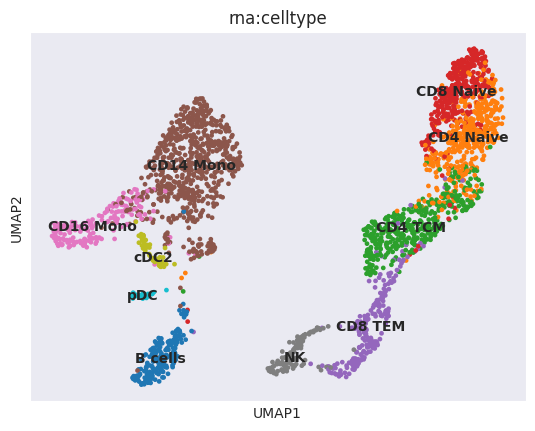

In [29]:
sc.pl.umap(model.adata, color=['rna:celltype'], wspace=0.15, show=True, legend_loc='on data')

In [30]:
# Compute latent Leiden clustering
latent_leiden_resolution = 1.0
latent_cluster_key = f"latent_leiden_{str(latent_leiden_resolution)}"
latent_key = "garfield_latent"

sc.tl.leiden(adata=model.adata,
             resolution=latent_leiden_resolution,
             key_added=latent_cluster_key,
             neighbors_key=latent_key)
len(model.adata.obs[latent_cluster_key].unique())

15

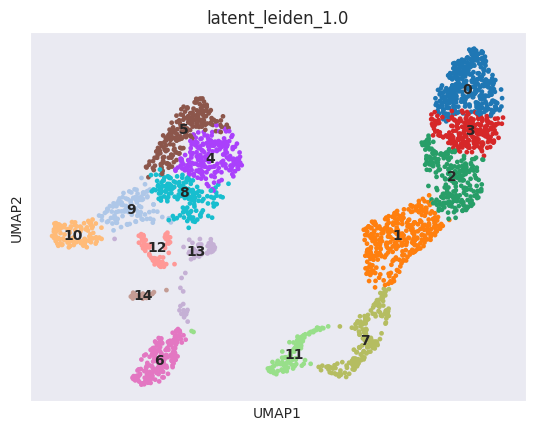

In [31]:
sc.pl.umap(model.adata, color=[latent_cluster_key], wspace=0.15, show=True, legend_loc='on data')

In [32]:
# Save trained model
model_folder_path = f"{workdir}/model"
os.makedirs(model_folder_path, exist_ok=True)

del model.adata.obsm['feat']
model.save(dir_path=model_folder_path,
           overwrite=True,
           save_adata=True,
           adata_file_name="adata_ref.h5ad")

Pickle failed with error: Can't pickle local object 'WeakSet.__init__.<locals>._remove', switching to dill...
Model saved successfully using dill at /data2/zhouwg_data/project/Garfield_benchmark/results/Vertical/RNA_ATAC/7_human_pbmc_10x/model/attr.pkl


In [33]:
# 获取潜在表示
import numpy as np

latent = model.adata.obsm['garfield_latent'].copy()
np.savetxt(os.path.join(workdir, "Garfield.csv"), latent, delimiter=',')

### 数据集 10_GSE201402_down

In [46]:
import os
os.chdir('/data2/zhouwg_data/project/Garfield')
os.getcwd()

'/data2/zhouwg_data/project/Garfield'

In [47]:
# load packages
import os
import warnings
import Garfield as gf
import scanpy as sc
from mudata import MuData
warnings.simplefilter(action="ignore", category=FutureWarning)
warnings.simplefilter(action='ignore', category=UserWarning)

gf.__version__

'0.3.8'

In [48]:
import pandas as pd
from scipy import io
from tqdm import tqdm

def check_file_exists(file_path):
    """Check if the file or directory exists and raise an error if not."""
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"The file or directory {file_path} does not exist.")

def read_rna_data(rna_dir):
    """Read RNA data including barcodes, features, and matrix from the specified directory."""
    rna_barcodes = pd.read_csv(f'{rna_dir}/barcodes.tsv', header=None, sep='\t', dtype=str)
    rna_features = pd.read_csv(f'{rna_dir}/features.tsv', header=None, sep='\t', dtype=str)
    rna_matrix = io.mmread(f'{rna_dir}/matrix.mtx').T.tocsr()

    rna = sc.AnnData(X=rna_matrix)
    rna.var['gene_symbols'] = rna_features.iloc[:, 0].values
    rna.obs['barcodes'] = rna_barcodes.iloc[:, 0].values
    rna.var_names = rna.var['gene_symbols']  # Set feature names
    rna.obs_names = rna.obs['barcodes']  # Set barcode names
    return rna

def read_atac_data(atac_dir):
    """Read ATAC data from the specified CSV file and return it as an AnnData object."""
    atac_barcodes = pd.read_csv(f'{atac_dir}/barcodes.tsv', header=None, sep='\t', dtype=str)
    atac_features = pd.read_csv(f'{atac_dir}/features.tsv', header=None, sep='\t', dtype=str)
    atac_matrix = io.mmread(f'{atac_dir}/matrix.mtx').T.tocsr()

    atac = sc.AnnData(X=atac_matrix)
    atac.var['gene_symbols'] = atac_features.iloc[:, 0].values
    atac.obs['barcodes'] = atac_barcodes.iloc[:, 0].values
    atac.var_names = atac.var['gene_symbols']  # Set feature names
    atac.obs_names = atac.obs['barcodes']  # Set barcode names
    return atac

def read_metadata(metadata_file):
    """Read metadata from a CSV file and return it as a DataFrame."""
    return pd.read_csv(metadata_file, index_col=0)

def read_multiomics_data(rna_dir, atac_dir, metadata_file):
    """
    Reads and processes RNA and ADT data, adding metadata to both.

    Parameters:
        rna_dir (str): Path to the directory containing RNA matrix, barcodes, and features.
        atac_file (str): Path to the CSV file containing ATAC data.
        metadata_file (str): Path to the CSV file containing metadata.

    Returns:
        dict: A dictionary with keys "rna" and "adt" containing the corresponding AnnData objects.
    """
    # Ensure all paths exist
    check_file_exists(rna_dir)
    check_file_exists(atac_dir)
    check_file_exists(metadata_file)

    # Use progress feedback to track steps
    with tqdm(total=3, desc="Reading multiomics data") as pbar:
        # Read RNA data
        rna = read_rna_data(rna_dir)
        pbar.update(1)

        # Read ADT data
        atac = read_atac_data(atac_dir)
        pbar.update(1)

        # Read metadata
        metadata = read_metadata(metadata_file)
        pbar.update(1)

    # Add metadata to RNA and ADT objects
    rna.obs = rna.obs.join(metadata, how="left")  # Ensure all metadata entries align
    atac.obs = atac.obs.join(metadata, how="left")

    return {"rna": rna, "atac": atac}

# Example usage with provided file paths
dataset = '10_GSE201402_down' #
rna_dir = f'/data2/zhouwg_data/project/Garfield_benchmark/datasets/MultiomicsBenchmark/Raw_data/RNA_ATAC/{dataset}/RNA'
atac_dir = f'/data2/zhouwg_data/project/Garfield_benchmark/datasets/MultiomicsBenchmark/Raw_data/RNA_ATAC/{dataset}/ATAC'
metadata_file = f'/data2/zhouwg_data/project/Garfield_benchmark/datasets/MultiomicsBenchmark/Raw_data/RNA_ATAC/{dataset}/meta_data.csv'

# Read the data
data = read_multiomics_data(rna_dir, atac_dir, metadata_file)

# Access RNA and ADT data separately
rna = data["rna"].copy()
atac = data["atac"].copy()
rna.layers['counts'] = rna.X.copy()
atac.layers['counts'] = atac.X.copy()

Reading multiomics data: 100%|██████████| 3/3 [00:01<00:00,  2.17it/s]


In [49]:
## load data
# rna.X = rna.X.toarray().astype(float)
# atac.X = atac.X.toarray().astype(float)
rna.var['feature_types'] = 'RNA'
atac.var['feature_types'] = 'ATAC'

# split each element for gene score calculation
split_data = atac.var_names.str.split('-', expand=True).to_frame(index=False)
split_data.index = atac.var_names
split_data.columns = ['chr', 'start', 'end']
atac.var[['chr', 'start', 'end']] = split_data

mdata = MuData({"rna": rna, "atac": atac})
mdata

MuData object with n_obs × n_vars = 9383 × 64651
  var:	'gene_symbols', 'feature_types'
  2 modalities
    rna:	9383 x 6275
      obs:	'barcodes', 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'RNA_snn_res.0.5', 'seurat_clusters', 'celltype'
      var:	'gene_symbols', 'feature_types'
      layers:	'counts'
    atac:	9383 x 58376
      obs:	'barcodes', 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'RNA_snn_res.0.5', 'seurat_clusters', 'celltype'
      var:	'gene_symbols', 'feature_types', 'chr', 'start', 'end'
      layers:	'counts'

In [50]:
# 定义genome类型
human_datasets = ["5_human_brain_10x", "6_pbmc_granulocyte_sorted_10x", "7_human_pbmc_10x",
                  "8_pbmc_unsorted_10k", "9_pbmc_unsorted_3k"]
mouse_datasets = ["1_ShareSeq_Skin", "2_brain_ShareSeq", "3_brain_SNARE","4_brain_ISSAAC_seq","10_GSE201402_down"]

if dataset in human_datasets:
    genome = 'hg38'
else:
    genome = 'mm10'

In [51]:
# set workdir
workdir = f'/data2/zhouwg_data/project/Garfield_benchmark/results/Vertical/RNA_ATAC/{dataset}'
gf.settings.set_workdir(workdir)

### modify parameter
user_config = dict(
    ## Input options
    adata_list=mdata,
    profile='multi-modal',   # if it is 'ATAC' or 'ADT', please adjust it.
    data_type='Paired',
    sub_data_type=['rna', 'atac'],
    sample_col=None,  # Specify columns for batch, only one batch, so set `None`
    weight=0.8,

    ## Preprocessing options
    genome=genome,
    use_gene_weight=True,
    use_top_pcs=False,
    used_hvg=True,
    min_cells=3,
    min_features=0,
    keep_mt=False,
    target_sum=1e4,
    rna_n_top_features=3000,
    atac_n_top_features=10000, # if data belongs to 'ATAC', please specify it.
    n_components=50,
    n_neighbors=5,
    metric='euclidean',
    svd_solver='arpack',
    # datasets
    used_pca_feat=True,
    adj_key='connectivities',

    # data split parameters
    edge_val_ratio=0.1,
    edge_test_ratio=0.,
    node_val_ratio=0.1,
    node_test_ratio=0.,

    ## Model options
    augment_type='svd',
    svd_q=5,
    use_FCencoder=False,
    conv_type='GATv2Conv', # GAT or GATv2Conv or GCN
    gnn_layer=2,
    hidden_dims=[128, 128],
    bottle_neck_neurons=20,
    cluster_num=20,
    drop_feature_rate=0.2,
    drop_edge_rate=0.2,
    num_heads=3,
    dropout=0.2,
    concat=True,
    used_edge_weight=True,
    used_DSBN=False,
    used_mmd=False,
    # data loader parameters
    num_neighbors=5,
    loaders_n_hops=2,
    edge_batch_size=4096,
    node_batch_size=128, # None
    # loss parameters
    include_edge_recon_loss=True,
    include_gene_expr_recon_loss=True,
    lambda_latent_contrastive_instanceloss=1.0,
    lambda_latent_contrastive_clusterloss=0.5,
    lambda_gene_expr_recon=1., # To make the model more focused on learning expression features, increase this parameter.
    lambda_edge_recon=50., # To make the model more focused on learning Adjacency graph features, increase this parameter.
    lambda_latent_adj_recon_loss=2.0,
    lambda_omics_recon_mmd_loss=3., # If the integration is not strong enough, increase it.
    # train parameters
    n_epochs_no_edge_recon=0,
    learning_rate=0.001,
    weight_decay=1e-05,
    gradient_clipping=5,
    # other parameters
    latent_key='garfield_latent',
    reload_best_model=True,
    use_early_stopping=True,
    early_stopping_kwargs=None,
    monitor=True,
    device_id=1,
    seed=2024,
    verbose=True
)
dict_config = gf.settings.set_gf_params(user_config)

Saving results in: /data2/zhouwg_data/project/Garfield_benchmark/results/Vertical/RNA_ATAC/10_GSE201402_down


In [52]:
from Garfield.model import Garfield

# Initialize model
model = Garfield(dict_config)

--- DATA LOADING AND PREPROCESSING ---
Gene activity matrix has been calculated, loading cached adata_CG_atac object...
There are 5939 common genes in RNA and ATAC datasets
To start performing cell matching for adjacency matrix of the graph, please wait...
Finding initial pivots...
Init_matching done!
Refining pivots...
Refined_matching done!
Filter_bad_matches on pivots matching...
Begin filtering...
6568/9383 pairs of matched cells remain after the filtering.
Fitting CCA on pivots...
Scoring matched pairs...
Propagating matching...
Done!
Filter_bad_matches on propagated matching...
Begin filtering...
5630/5630 pairs of matched cells remain after the filtering.
Fitting CCA on pivots...
Scoring matched pairs...
COSINE SIM GRAPH DECODER -> dropout_rate: 0.2


In [53]:
# Train model
model.train()


--- INITIALIZING TRAINER ---
Using GPU: 1
Number of training nodes: 8445
Number of validation nodes: 938
Number of training edges: 65820
Number of validation edges: 7313
Edge batch size: 4096
Node batch size: 128

--- MODEL TRAINING ---
Epoch 1/100 |--------------------| 1.0% val_auroc_score: 0.8348; val_auprc_score: 0.8184; val_best_acc_score: 0.7447; val_best_f1_score: 0.7759; train_kl_reg_loss: 25376.8262; train_edge_recon_loss: 53369.0449; train_gene_expr_recon_loss: 3339078.1282; train_lambda_latent_adj_recon_loss: 1751.6865; train_lambda_latent_contrastive_instanceloss: 7.1821; train_lambda_latent_contrastive_clusterloss: 3.7200; train_global_loss: 3419586.4596; train_optim_loss: 3419586.4596; val_kl_reg_loss: 80.7488; val_edge_recon_loss: 46347.4785; val_gene_expr_recon_loss: 91620.6797; val_lambda_latent_adj_recon_loss: 1410.5726; val_lambda_latent_contrastive_instanceloss: 6.8465; val_lambda_latent_contrastive_clusterloss: 3.5954; val_global_loss: 139469.9219; val_optim_loss:

In [54]:
# Compute latent neighbor graph
latent_key = 'garfield_latent'
sc.pp.neighbors(model.adata,
                use_rep=latent_key,
                key_added=latent_key)
# Compute UMAP embedding
sc.tl.umap(model.adata,
           neighbors_key=latent_key)

In [55]:
model.adata

AnnData object with n_obs × n_vars = 9383 × 13000
    obs: 'rna:barcodes', 'rna:orig.ident', 'rna:nCount_RNA', 'rna:nFeature_RNA', 'rna:RNA_snn_res.0.5', 'rna:seurat_clusters', 'rna:celltype', 'rna:n_genes', 'atac:barcodes', 'atac:orig.ident', 'atac:nCount_RNA', 'atac:nFeature_RNA', 'atac:RNA_snn_res.0.5', 'atac:seurat_clusters', 'atac:celltype', 'atac:n_genes'
    var: 'gene_symbols', 'feature_types', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'garfield_latent', 'umap'
    obsm: 'feat', 'garfield_latent', 'X_umap'
    varm: 'PCs'
    layers: 'counts', 'norm_data'
    obsp: 'connectivities', 'garfield_latent_distances', 'garfield_latent_connectivities'

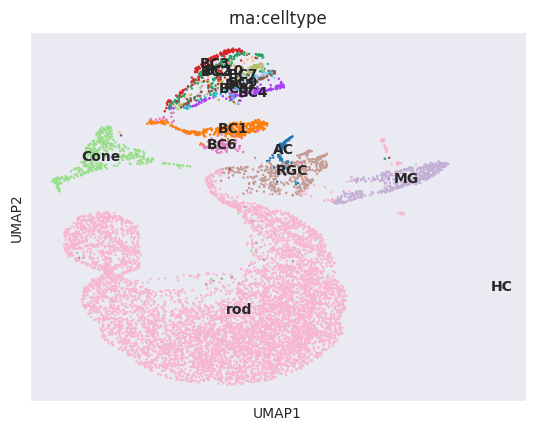

In [56]:
sc.pl.umap(model.adata, color=['rna:celltype'], wspace=0.15, show=True, legend_loc='on data')

In [57]:
# Compute latent Leiden clustering
latent_leiden_resolution = 1.0
latent_cluster_key = f"latent_leiden_{str(latent_leiden_resolution)}"
latent_key = "garfield_latent"

sc.tl.leiden(adata=model.adata,
             resolution=latent_leiden_resolution,
             key_added=latent_cluster_key,
             neighbors_key=latent_key)
len(model.adata.obs[latent_cluster_key].unique())

26

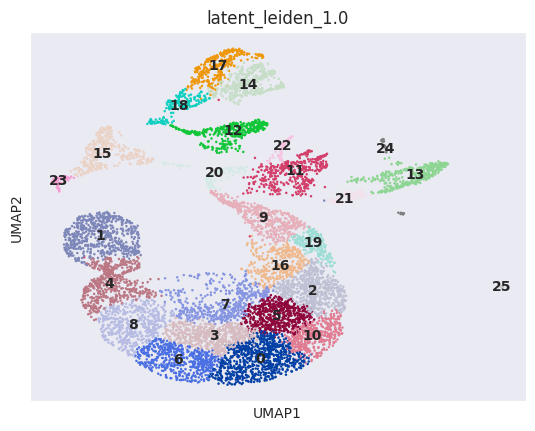

In [58]:
sc.pl.umap(model.adata, color=[latent_cluster_key], wspace=0.15, show=True, legend_loc='on data')

In [59]:
# Save trained model
model_folder_path = f"{workdir}/model"
os.makedirs(model_folder_path, exist_ok=True)

del model.adata.obsm['feat']
model.save(dir_path=model_folder_path,
           overwrite=True,
           save_adata=True,
           adata_file_name="adata_ref.h5ad")

Pickle failed with error: Can't pickle local object 'WeakSet.__init__.<locals>._remove', switching to dill...
Model saved successfully using dill at /data2/zhouwg_data/project/Garfield_benchmark/results/Vertical/RNA_ATAC/10_GSE201402_down/model/attr.pkl


In [60]:
# 获取潜在表示
import numpy as np

latent = model.adata.obsm['garfield_latent'].copy()
np.savetxt(os.path.join(workdir, "Garfield.csv"), latent, delimiter=',')

### 数据集9_pbmc_unsorted_3k

In [1]:
import os
os.chdir('/data2/zhouwg_data/project/Garfield')
os.getcwd()

'/data2/zhouwg_data/project/Garfield'

In [2]:
# load packages
import os
import warnings
import Garfield as gf
import scanpy as sc
from mudata import MuData
warnings.simplefilter(action="ignore", category=FutureWarning)
warnings.simplefilter(action='ignore', category=UserWarning)

gf.__version__

/home/zhouweige/anaconda3/envs/env_gf_test/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


'0.3.8'

In [3]:
import pandas as pd
from scipy import io
from tqdm import tqdm

def check_file_exists(file_path):
    """Check if the file or directory exists and raise an error if not."""
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"The file or directory {file_path} does not exist.")

def read_rna_data(rna_dir):
    """Read RNA data including barcodes, features, and matrix from the specified directory."""
    rna_barcodes = pd.read_csv(f'{rna_dir}/barcodes.tsv', header=None, sep='\t', dtype=str)
    rna_features = pd.read_csv(f'{rna_dir}/features.tsv', header=None, sep='\t', dtype=str)
    rna_matrix = io.mmread(f'{rna_dir}/matrix.mtx').T.tocsr()

    rna = sc.AnnData(X=rna_matrix)
    rna.var['gene_symbols'] = rna_features.iloc[:, 0].values
    rna.obs['barcodes'] = rna_barcodes.iloc[:, 0].values
    rna.var_names = rna.var['gene_symbols']  # Set feature names
    rna.obs_names = rna.obs['barcodes']  # Set barcode names
    return rna

def read_atac_data(atac_dir):
    """Read ATAC data from the specified CSV file and return it as an AnnData object."""
    atac_barcodes = pd.read_csv(f'{atac_dir}/barcodes.tsv', header=None, sep='\t', dtype=str)
    atac_features = pd.read_csv(f'{atac_dir}/features.tsv', header=None, sep='\t', dtype=str)
    atac_matrix = io.mmread(f'{atac_dir}/matrix.mtx').T.tocsr()

    atac = sc.AnnData(X=atac_matrix)
    atac.var['gene_symbols'] = atac_features.iloc[:, 0].values
    atac.obs['barcodes'] = atac_barcodes.iloc[:, 0].values
    atac.var_names = atac.var['gene_symbols']  # Set feature names
    atac.obs_names = atac.obs['barcodes']  # Set barcode names
    return atac

def read_metadata(metadata_file):
    """Read metadata from a CSV file and return it as a DataFrame."""
    return pd.read_csv(metadata_file, index_col=0)

def read_multiomics_data(rna_dir, atac_dir, metadata_file):
    """
    Reads and processes RNA and ADT data, adding metadata to both.

    Parameters:
        rna_dir (str): Path to the directory containing RNA matrix, barcodes, and features.
        atac_file (str): Path to the CSV file containing ATAC data.
        metadata_file (str): Path to the CSV file containing metadata.

    Returns:
        dict: A dictionary with keys "rna" and "adt" containing the corresponding AnnData objects.
    """
    # Ensure all paths exist
    check_file_exists(rna_dir)
    check_file_exists(atac_dir)
    check_file_exists(metadata_file)

    # Use progress feedback to track steps
    with tqdm(total=3, desc="Reading multiomics data") as pbar:
        # Read RNA data
        rna = read_rna_data(rna_dir)
        pbar.update(1)

        # Read ADT data
        atac = read_atac_data(atac_dir)
        pbar.update(1)

        # Read metadata
        metadata = read_metadata(metadata_file)
        pbar.update(1)

    # Add metadata to RNA and ADT objects
    rna.obs = rna.obs.join(metadata, how="left")  # Ensure all metadata entries align
    atac.obs = atac.obs.join(metadata, how="left")

    return {"rna": rna, "atac": atac}

# Example usage with provided file paths
dataset = '9_pbmc_unsorted_3k' #
rna_dir = f'/data2/zhouwg_data/project/Garfield_benchmark/datasets/MultiomicsBenchmark/Raw_data/RNA_ATAC/{dataset}/RNA'
atac_dir = f'/data2/zhouwg_data/project/Garfield_benchmark/datasets/MultiomicsBenchmark/Raw_data/RNA_ATAC/{dataset}/ATAC'
metadata_file = f'/data2/zhouwg_data/project/Garfield_benchmark/datasets/MultiomicsBenchmark/Raw_data/RNA_ATAC/{dataset}/meta_data.csv'

# Read the data
data = read_multiomics_data(rna_dir, atac_dir, metadata_file)

# Access RNA and ADT data separately
rna = data["rna"].copy()
atac = data["atac"].copy()
rna.layers['counts'] = rna.X.copy()
atac.layers['counts'] = atac.X.copy()

Reading multiomics data: 100%|██████████| 3/3 [00:01<00:00,  2.69it/s]


In [4]:
## load data
# rna.X = rna.X.toarray().astype(float)
# atac.X = atac.X.toarray().astype(float)
rna.var['feature_types'] = 'RNA'
atac.var['feature_types'] = 'ATAC'

# split each element for gene score calculation
split_data = atac.var_names.str.split('-', expand=True).to_frame(index=False)
split_data.index = atac.var_names
split_data.columns = ['chr', 'start', 'end']
atac.var[['chr', 'start', 'end']] = split_data

mdata = MuData({"rna": rna, "atac": atac})
mdata

MuData object with n_obs × n_vars = 2413 × 114819
  var:	'gene_symbols', 'feature_types'
  2 modalities
    rna:	2413 x 36601
      obs:	'barcodes', 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'nCount_ATAC', 'nFeature_ATAC', 'TSS.enrichment', 'TSS.percentile', 'nucleosome_signal', 'nucleosome_percentile', 'fragments', 'FRiP', 'blacklist_fraction', 'percent.mt', 'percent.ribo', 'ATAC_snn_res.0.8', 'seurat_clusters', 'nCount_SCT', 'nFeature_SCT', 'SCT_snn_res.0.8', 'predicted.id', 'celltype', 'SCT.weight', 'ATAC.weight', 'wsnn_res.0.8', 'nCount_aRNA', 'nFeature_aRNA', 'aRNA_snn_res.0.8'
      var:	'gene_symbols', 'feature_types'
      layers:	'counts'
    atac:	2413 x 78218
      obs:	'barcodes', 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'nCount_ATAC', 'nFeature_ATAC', 'TSS.enrichment', 'TSS.percentile', 'nucleosome_signal', 'nucleosome_percentile', 'fragments', 'FRiP', 'blacklist_fraction', 'percent.mt', 'percent.ribo', 'ATAC_snn_res.0.8', 'seurat_clusters', 'nCount_SCT', 'nFeature_SCT', 'SCT_snn_res.0.8', 'predicted.id', 'celltype', 'SCT.weight', 'ATAC.weight', 'wsnn_res.0.8', 'nCount_aRNA', 'nFeature_aRNA', 'aRNA_snn_res.0.8'
      var:	'gene_symbols', 'feature_types', 'chr', 'start', 'end'
      layers:	'counts'

In [5]:
# 定义genome类型
human_datasets = ["5_human_brain_10x", "6_pbmc_granulocyte_sorted_10x", "7_human_pbmc_10x",
                  "8_pbmc_unsorted_10k", "9_pbmc_unsorted_3k"]
mouse_datasets = ["1_ShareSeq_Skin", "2_brain_ShareSeq", "3_brain_SNARE","4_brain_ISSAAC_seq","10_GSE201402_down"]

if dataset in human_datasets:
    genome = 'hg38'
else:
    genome = 'mm10'

In [6]:
# set workdir
workdir = f'/data2/zhouwg_data/project/Garfield_benchmark/results/Vertical/RNA_ATAC/{dataset}'
gf.settings.set_workdir(workdir)

### modify parameter
user_config = dict(
    ## Input options
    adata_list=mdata,
    profile='multi-modal',   # if it is 'ATAC' or 'ADT', please adjust it.
    data_type='Paired',
    sub_data_type=['rna', 'atac'],
    sample_col=None,  # Specify columns for batch, only one batch, so set `None`
    weight=0.8,

    ## Preprocessing options
    genome=genome,
    use_gene_weight=True,
    use_top_pcs=False,
    used_hvg=True,
    min_cells=3,
    min_features=0,
    keep_mt=False,
    target_sum=1e4,
    rna_n_top_features=3000,
    atac_n_top_features=10000, # if data belongs to 'ATAC', please specify it.
    n_components=50,
    n_neighbors=5,
    metric='euclidean',
    svd_solver='arpack',
    # datasets
    used_pca_feat=True,
    adj_key='connectivities',

    # data split parameters
    edge_val_ratio=0.1,
    edge_test_ratio=0.,
    node_val_ratio=0.1,
    node_test_ratio=0.,

    ## Model options
    augment_type='svd',
    svd_q=5,
    use_FCencoder=False,
    conv_type='GATv2Conv', # GAT or GATv2Conv or GCN
    gnn_layer=2,
    hidden_dims=[128, 128],
    bottle_neck_neurons=20,
    cluster_num=20,
    drop_feature_rate=0.2,
    drop_edge_rate=0.2,
    num_heads=3,
    dropout=0.2,
    concat=True,
    used_edge_weight=False,
    used_DSBN=False,
    used_mmd=False,
    # data loader parameters
    num_neighbors=5,
    loaders_n_hops=2,
    edge_batch_size=4096,
    node_batch_size=128, # None
    # loss parameters
    include_edge_recon_loss=True,
    include_gene_expr_recon_loss=True,
    lambda_latent_contrastive_instanceloss=1.0,
    lambda_latent_contrastive_clusterloss=0.5,
    lambda_gene_expr_recon=1., # To make the model more focused on learning expression features, increase this parameter.
    lambda_edge_recon=50., # To make the model more focused on learning Adjacency graph features, increase this parameter.
    lambda_latent_adj_recon_loss=2.0,
    lambda_omics_recon_mmd_loss=3., # If the integration is not strong enough, increase it.
    # train parameters
    n_epochs_no_edge_recon=0,
    learning_rate=0.001,
    weight_decay=1e-05,
    gradient_clipping=5,
    # other parameters
    latent_key='garfield_latent',
    reload_best_model=True,
    use_early_stopping=True,
    early_stopping_kwargs=None,
    monitor=True,
    device_id=1,
    seed=2024,
    verbose=True
)
dict_config = gf.settings.set_gf_params(user_config)

Saving results in: /data2/zhouwg_data/project/Garfield_benchmark/results/Vertical/RNA_ATAC/9_pbmc_unsorted_3k


In [7]:
from Garfield.model import Garfield

# Initialize model
model = Garfield(dict_config)

--- DATA LOADING AND PREPROCESSING ---
Gene activity matrix has been calculated, loading cached adata_CG_atac object...
There are 16005 common genes in RNA and ATAC datasets
To start performing cell matching for adjacency matrix of the graph, please wait...
Finding initial pivots...
Init_matching done!
Refining pivots...
Refined_matching done!
Filter_bad_matches on pivots matching...
Begin filtering...
1689/2413 pairs of matched cells remain after the filtering.
Fitting CCA on pivots...
Scoring matched pairs...
Propagating matching...
Done!
Filter_bad_matches on propagated matching...
Begin filtering...
1448/1448 pairs of matched cells remain after the filtering.
Fitting CCA on pivots...
Scoring matched pairs...
COSINE SIM GRAPH DECODER -> dropout_rate: 0.2


In [8]:
# Train model
model.train()


--- INITIALIZING TRAINER ---
Using GPU: 1
Number of training nodes: 2172
Number of validation nodes: 241
Number of training edges: 16493
Number of validation edges: 1832
Edge batch size: 4096
Node batch size: 128

--- MODEL TRAINING ---
Epoch 1/100 |--------------------| 1.0% val_auroc_score: 0.8440; val_auprc_score: 0.8259; val_best_acc_score: 0.7697; val_best_f1_score: 0.7853; train_kl_reg_loss: 1457744.0160; train_edge_recon_loss: 45942.9410; train_gene_expr_recon_loss: 22149112.2250; train_lambda_latent_adj_recon_loss: 2995.3855; train_lambda_latent_contrastive_instanceloss: 7.1166; train_lambda_latent_contrastive_clusterloss: 3.7012; train_global_loss: 23655806.4000; train_optim_loss: 23655806.4000; val_kl_reg_loss: 456279.5312; val_edge_recon_loss: 25280.2539; val_gene_expr_recon_loss: 1313252.3750; val_lambda_latent_adj_recon_loss: 1324.3016; val_lambda_latent_contrastive_instanceloss: 6.8002; val_lambda_latent_contrastive_clusterloss: 3.6908; val_global_loss: 1796146.8750; val

In [9]:
# Compute latent neighbor graph
latent_key = 'garfield_latent'
sc.pp.neighbors(model.adata,
                use_rep=latent_key,
                key_added=latent_key)
# Compute UMAP embedding
sc.tl.umap(model.adata,
           neighbors_key=latent_key)

In [10]:
model.adata

AnnData object with n_obs × n_vars = 2413 × 13000
    obs: 'rna:barcodes', 'rna:orig.ident', 'rna:nCount_RNA', 'rna:nFeature_RNA', 'rna:nCount_ATAC', 'rna:nFeature_ATAC', 'rna:TSS.enrichment', 'rna:TSS.percentile', 'rna:nucleosome_signal', 'rna:nucleosome_percentile', 'rna:fragments', 'rna:FRiP', 'rna:blacklist_fraction', 'rna:percent.mt', 'rna:percent.ribo', 'rna:ATAC_snn_res.0.8', 'rna:seurat_clusters', 'rna:nCount_SCT', 'rna:nFeature_SCT', 'rna:SCT_snn_res.0.8', 'rna:predicted.id', 'rna:celltype', 'rna:SCT.weight', 'rna:ATAC.weight', 'rna:wsnn_res.0.8', 'rna:nCount_aRNA', 'rna:nFeature_aRNA', 'rna:aRNA_snn_res.0.8', 'rna:n_genes', 'atac:barcodes', 'atac:orig.ident', 'atac:nCount_RNA', 'atac:nFeature_RNA', 'atac:nCount_ATAC', 'atac:nFeature_ATAC', 'atac:TSS.enrichment', 'atac:TSS.percentile', 'atac:nucleosome_signal', 'atac:nucleosome_percentile', 'atac:fragments', 'atac:FRiP', 'atac:blacklist_fraction', 'atac:percent.mt', 'atac:percent.ribo', 'atac:ATAC_snn_res.0.8', 'atac:seurat_cl

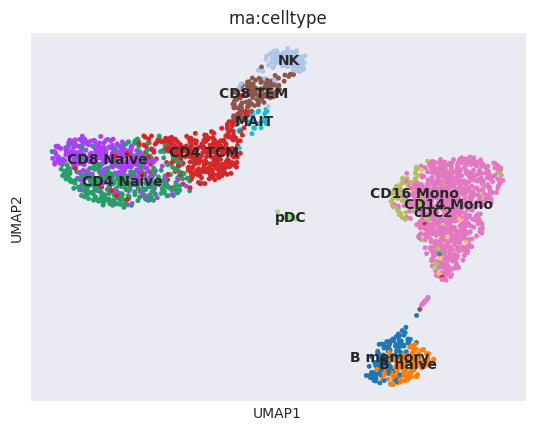

In [11]:
sc.pl.umap(model.adata, color=['rna:celltype'], wspace=0.15, show=True, legend_loc='on data')

In [14]:
# Compute latent Leiden clustring
latent_leiden_resolution = 1.0
latent_cluster_key = f"latent_leiden_{str(latent_leiden_resolution)}"
latent_key = "garfield_latent"

sc.tl.leiden(adata=model.adata,
             resolution=latent_leiden_resolution,
             key_added=latent_cluster_key,
             neighbors_key=latent_key)
len(model.adata.obs[latent_cluster_key].unique())

15

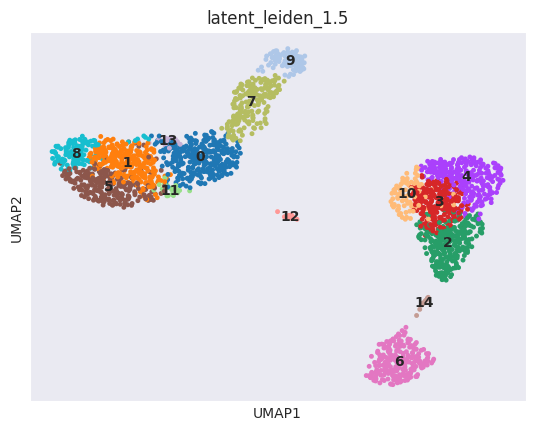

In [15]:
sc.pl.umap(model.adata, color=[latent_cluster_key], wspace=0.15, show=True, legend_loc='on data')

In [16]:
# Save trained model
model_folder_path = f"{workdir}/model"
os.makedirs(model_folder_path, exist_ok=True)

del model.adata.obsm['feat']
model.save(dir_path=model_folder_path,
           overwrite=True,
           save_adata=True,
           adata_file_name="adata_ref.h5ad")

Pickle failed with error: Can't pickle local object 'WeakSet.__init__.<locals>._remove', switching to dill...
Model saved successfully using dill at /data2/zhouwg_data/project/Garfield_benchmark/results/Vertical/RNA_ATAC/9_pbmc_unsorted_3k/model/attr.pkl


In [17]:
# 获取潜在表示
import numpy as np

latent = model.adata.obsm['garfield_latent'].copy()
np.savetxt(os.path.join(workdir, "Garfield.csv"), latent, delimiter=',')

### 数据集 8_pbmc_unsorted_10k

In [34]:
import os
os.chdir('/data2/zhouwg_data/project/Garfield')
os.getcwd()

'/data2/zhouwg_data/project/Garfield'

In [35]:
# load packages
import os
import warnings
import Garfield as gf
import scanpy as sc
from mudata import MuData
warnings.simplefilter(action="ignore", category=FutureWarning)
warnings.simplefilter(action='ignore', category=UserWarning)

gf.__version__

'0.3.8'

In [36]:
import pandas as pd
from scipy import io
from tqdm import tqdm

def check_file_exists(file_path):
    """Check if the file or directory exists and raise an error if not."""
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"The file or directory {file_path} does not exist.")

def read_rna_data(rna_dir):
    """Read RNA data including barcodes, features, and matrix from the specified directory."""
    rna_barcodes = pd.read_csv(f'{rna_dir}/barcodes.tsv', header=None, sep='\t', dtype=str)
    rna_features = pd.read_csv(f'{rna_dir}/features.tsv', header=None, sep='\t', dtype=str)
    rna_matrix = io.mmread(f'{rna_dir}/matrix.mtx').T.tocsr()

    rna = sc.AnnData(X=rna_matrix)
    rna.var['gene_symbols'] = rna_features.iloc[:, 0].values
    rna.obs['barcodes'] = rna_barcodes.iloc[:, 0].values
    rna.var_names = rna.var['gene_symbols']  # Set feature names
    rna.obs_names = rna.obs['barcodes']  # Set barcode names
    return rna

def read_atac_data(atac_dir):
    """Read ATAC data from the specified CSV file and return it as an AnnData object."""
    atac_barcodes = pd.read_csv(f'{atac_dir}/barcodes.tsv', header=None, sep='\t', dtype=str)
    atac_features = pd.read_csv(f'{atac_dir}/features.tsv', header=None, sep='\t', dtype=str)
    atac_matrix = io.mmread(f'{atac_dir}/matrix.mtx').T.tocsr()

    atac = sc.AnnData(X=atac_matrix)
    atac.var['gene_symbols'] = atac_features.iloc[:, 0].values
    atac.obs['barcodes'] = atac_barcodes.iloc[:, 0].values
    atac.var_names = atac.var['gene_symbols']  # Set feature names
    atac.obs_names = atac.obs['barcodes']  # Set barcode names
    return atac

def read_metadata(metadata_file):
    """Read metadata from a CSV file and return it as a DataFrame."""
    return pd.read_csv(metadata_file, index_col=0)

def read_multiomics_data(rna_dir, atac_dir, metadata_file):
    """
    Reads and processes RNA and ADT data, adding metadata to both.

    Parameters:
        rna_dir (str): Path to the directory containing RNA matrix, barcodes, and features.
        atac_file (str): Path to the CSV file containing ATAC data.
        metadata_file (str): Path to the CSV file containing metadata.

    Returns:
        dict: A dictionary with keys "rna" and "adt" containing the corresponding AnnData objects.
    """
    # Ensure all paths exist
    check_file_exists(rna_dir)
    check_file_exists(atac_dir)
    check_file_exists(metadata_file)

    # Use progress feedback to track steps
    with tqdm(total=3, desc="Reading multiomics data") as pbar:
        # Read RNA data
        rna = read_rna_data(rna_dir)
        pbar.update(1)

        # Read ADT data
        atac = read_atac_data(atac_dir)
        pbar.update(1)

        # Read metadata
        metadata = read_metadata(metadata_file)
        pbar.update(1)

    # Add metadata to RNA and ADT objects
    rna.obs = rna.obs.join(metadata, how="left")  # Ensure all metadata entries align
    atac.obs = atac.obs.join(metadata, how="left")

    return {"rna": rna, "atac": atac}

# Example usage with provided file paths
dataset = '8_pbmc_unsorted_10k' #
rna_dir = f'/data2/zhouwg_data/project/Garfield_benchmark/datasets/MultiomicsBenchmark/Raw_data/RNA_ATAC/{dataset}/RNA'
atac_dir = f'/data2/zhouwg_data/project/Garfield_benchmark/datasets/MultiomicsBenchmark/Raw_data/RNA_ATAC/{dataset}/ATAC'
metadata_file = f'/data2/zhouwg_data/project/Garfield_benchmark/datasets/MultiomicsBenchmark/Raw_data/RNA_ATAC/{dataset}/meta_data.csv'

# Read the data
data = read_multiomics_data(rna_dir, atac_dir, metadata_file)

# Access RNA and ADT data separately
rna = data["rna"].copy()
atac = data["atac"].copy()
rna.layers['counts'] = rna.X.copy()
atac.layers['counts'] = atac.X.copy()

Reading multiomics data: 100%|██████████| 3/3 [00:06<00:00,  2.16s/it]


In [37]:
## load data
# rna.X = rna.X.toarray().astype(float)
# atac.X = atac.X.toarray().astype(float)
rna.var['feature_types'] = 'RNA'
atac.var['feature_types'] = 'ATAC'

# split each element for gene score calculation
split_data = atac.var_names.str.split('-', expand=True).to_frame(index=False)
split_data.index = atac.var_names
split_data.columns = ['chr', 'start', 'end']
atac.var[['chr', 'start', 'end']] = split_data

mdata = MuData({"rna": rna, "atac": atac})
mdata

MuData object with n_obs × n_vars = 8105 × 145206
  var:	'gene_symbols', 'feature_types'
  2 modalities
    rna:	8105 x 36601
      obs:	'barcodes', 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'nCount_ATAC', 'nFeature_ATAC', 'TSS.enrichment', 'TSS.percentile', 'nucleosome_signal', 'nucleosome_percentile', 'fragments', 'FRiP', 'blacklist_fraction', 'percent.mt', 'percent.ribo', 'ATAC_snn_res.0.8', 'seurat_clusters', 'nCount_SCT', 'nFeature_SCT', 'SCT_snn_res.0.8', 'predicted.id', 'SCT_snn_res.1', 'SCT_snn_res.1.2', 'celltype', 'SCT.weight', 'ATAC.weight', 'wsnn_res.0.8', 'nCount_aRNA', 'nFeature_aRNA', 'aRNA_snn_res.0.8'
      var:	'gene_symbols', 'feature_types'
      layers:	'counts'
    atac:	8105 x 108605
      obs:	'barcodes', 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'nCount_ATAC', 'nFeature_ATAC', 'TSS.enrichment', 'TSS.percentile', 'nucleosome_signal', 'nucleosome_percentile', 'fragments', 'FRiP', 'blacklist_fraction', 'percent.mt', 'percent.ribo', 'ATAC_snn_res.0.8', 'seurat_clusters', 'nCount_SCT', 'nFeature_SCT', 'SCT_snn_res.0.8', 'predicted.id', 'SCT_snn_res.1', 'SCT_snn_res.1.2', 'celltype', 'SCT.weight', 'ATAC.weight', 'wsnn_res.0.8', 'nCount_aRNA', 'nFeature_aRNA', 'aRNA_snn_res.0.8'
      var:	'gene_symbols', 'feature_types', 'chr', 'start', 'end'
      layers:	'counts'

In [38]:
# 定义genome类型
human_datasets = ["5_human_brain_10x", "6_pbmc_granulocyte_sorted_10x", "7_human_pbmc_10x",
                  "8_pbmc_unsorted_10k", "9_pbmc_unsorted_3k"]
mouse_datasets = ["1_ShareSeq_Skin", "2_brain_ShareSeq", "3_brain_SNARE","4_brain_ISSAAC_seq","10_GSE201402_down"]

if dataset in human_datasets:
    genome = 'hg38'
else:
    genome = 'mm10'

In [39]:
# set workdir
workdir = f'/data2/zhouwg_data/project/Garfield_benchmark/results/Vertical/RNA_ATAC/{dataset}'
gf.settings.set_workdir(workdir)

### modify parameter
user_config = dict(
    ## Input options
    adata_list=mdata,
    profile='multi-modal',   # if it is 'ATAC' or 'ADT', please adjust it.
    data_type='Paired',
    sub_data_type=['rna', 'atac'],
    sample_col=None,  # Specify columns for batch, only one batch, so set `None`
    weight=0.8,

    ## Preprocessing options
    genome=genome,
    use_gene_weight=True,
    use_top_pcs=False,
    used_hvg=True,
    min_cells=3,
    min_features=0,
    keep_mt=False,
    target_sum=1e4,
    rna_n_top_features=3000,
    atac_n_top_features=10000, # if data belongs to 'ATAC', please specify it.
    n_components=50,
    n_neighbors=5,
    metric='euclidean',
    svd_solver='arpack',
    # datasets
    used_pca_feat=True,
    adj_key='connectivities',

    # data split parameters
    edge_val_ratio=0.1,
    edge_test_ratio=0.,
    node_val_ratio=0.1,
    node_test_ratio=0.,

    ## Model options
    augment_type='svd',
    svd_q=5,
    use_FCencoder=False,
    conv_type='GATv2Conv', # GAT or GATv2Conv or GCN
    gnn_layer=2,
    hidden_dims=[128, 128],
    bottle_neck_neurons=20,
    cluster_num=20,
    drop_feature_rate=0.2,
    drop_edge_rate=0.2,
    num_heads=3,
    dropout=0.2,
    concat=True,
    used_edge_weight=True,
    used_DSBN=False,
    used_mmd=False,
    # data loader parameters
    num_neighbors=5,
    loaders_n_hops=2,
    edge_batch_size=4096,
    node_batch_size=128, # None
    # loss parameters
    include_edge_recon_loss=True,
    include_gene_expr_recon_loss=True,
    lambda_latent_contrastive_instanceloss=1.0,
    lambda_latent_contrastive_clusterloss=0.5,
    lambda_gene_expr_recon=1., # To make the model more focused on learning expression features, increase this parameter.
    lambda_edge_recon=50., # To make the model more focused on learning Adjacency graph features, increase this parameter.
    lambda_latent_adj_recon_loss=2.0,
    lambda_omics_recon_mmd_loss=3., # If the integration is not strong enough, increase it.
    # train parameters
    n_epochs_no_edge_recon=0,
    learning_rate=0.001,
    weight_decay=1e-05,
    gradient_clipping=5,
    # other parameters
    latent_key='garfield_latent',
    reload_best_model=True,
    use_early_stopping=True,
    early_stopping_kwargs=None,
    monitor=True,
    device_id=1,
    seed=2024,
    verbose=True
)
dict_config = gf.settings.set_gf_params(user_config)

Saving results in: /data2/zhouwg_data/project/Garfield_benchmark/results/Vertical/RNA_ATAC/8_pbmc_unsorted_10k


In [40]:
from Garfield.model import Garfield

# Initialize model
model = Garfield(dict_config)

--- DATA LOADING AND PREPROCESSING ---
Gene activity matrix has been calculated, loading cached adata_CG_atac object...
There are 18409 common genes in RNA and ATAC datasets
To start performing cell matching for adjacency matrix of the graph, please wait...
Finding initial pivots...
The first data is split into 1 batches, average batch size is 8105, and max batch size is 8105.
The second data is split into 1 batches, average batch size is 8105, and max batch size is 8105.
Batch to batch correspondence is:
  ['0<->0'].
Now at batch 0<->0...
Init_matching done!
Refining pivots...
Now at batch 0<->0...
Refined_matching done!
Filter_bad_matches on pivots matching...
Begin filtering...
5673/8105 pairs of matched cells remain after the filtering.
Fitting CCA on pivots...
Scoring matched pairs...
Propagating matching...
Now at batch 0<->0...
Done!
Filter_bad_matches on propagated matching...
Begin filtering...
4864/4864 pairs of matched cells remain after the filtering.
Fitting CCA on pivots.

In [41]:
# Train model
model.train()


--- INITIALIZING TRAINER ---
Using GPU: 1
Number of training nodes: 7295
Number of validation nodes: 810
Number of training edges: 55869
Number of validation edges: 6207
Edge batch size: 4096
Node batch size: 128

--- MODEL TRAINING ---
Epoch 1/100 |--------------------| 1.0% val_auroc_score: 0.8395; val_auprc_score: 0.8258; val_best_acc_score: 0.7657; val_best_f1_score: 0.7930; train_kl_reg_loss: 182.2246; train_edge_recon_loss: 52524.1507; train_gene_expr_recon_loss: 137615.1362; train_lambda_latent_adj_recon_loss: 2742.6662; train_lambda_latent_contrastive_instanceloss: 7.0542; train_lambda_latent_contrastive_clusterloss: 3.6833; train_global_loss: 193074.9163; train_optim_loss: 193074.9163; val_kl_reg_loss: 171.9232; val_edge_recon_loss: 39195.7920; val_gene_expr_recon_loss: 100701.0078; val_lambda_latent_adj_recon_loss: 3846.2616; val_lambda_latent_contrastive_instanceloss: 6.7739; val_lambda_latent_contrastive_clusterloss: 3.5669; val_global_loss: 143925.3164; val_optim_loss: 14

In [42]:
# Compute latent neighbor graph
latent_key = 'garfield_latent'
sc.pp.neighbors(model.adata,
                use_rep=latent_key,
                key_added=latent_key)
# Compute UMAP embedding
sc.tl.umap(model.adata,
           neighbors_key=latent_key)

In [43]:
model.adata

AnnData object with n_obs × n_vars = 8105 × 13000
    obs: 'rna:barcodes', 'rna:orig.ident', 'rna:nCount_RNA', 'rna:nFeature_RNA', 'rna:nCount_ATAC', 'rna:nFeature_ATAC', 'rna:TSS.enrichment', 'rna:TSS.percentile', 'rna:nucleosome_signal', 'rna:nucleosome_percentile', 'rna:fragments', 'rna:FRiP', 'rna:blacklist_fraction', 'rna:percent.mt', 'rna:percent.ribo', 'rna:ATAC_snn_res.0.8', 'rna:seurat_clusters', 'rna:nCount_SCT', 'rna:nFeature_SCT', 'rna:SCT_snn_res.0.8', 'rna:predicted.id', 'rna:SCT_snn_res.1', 'rna:SCT_snn_res.1.2', 'rna:celltype', 'rna:SCT.weight', 'rna:ATAC.weight', 'rna:wsnn_res.0.8', 'rna:nCount_aRNA', 'rna:nFeature_aRNA', 'rna:aRNA_snn_res.0.8', 'rna:n_genes', 'atac:barcodes', 'atac:orig.ident', 'atac:nCount_RNA', 'atac:nFeature_RNA', 'atac:nCount_ATAC', 'atac:nFeature_ATAC', 'atac:TSS.enrichment', 'atac:TSS.percentile', 'atac:nucleosome_signal', 'atac:nucleosome_percentile', 'atac:fragments', 'atac:FRiP', 'atac:blacklist_fraction', 'atac:percent.mt', 'atac:percent.rib

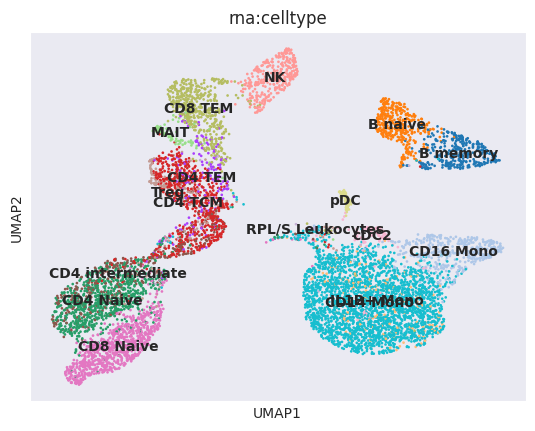

In [44]:
sc.pl.umap(model.adata, color=['rna:celltype'], wspace=0.15, show=True, legend_loc='on data')

In [45]:
# Compute latent Leiden clustering
latent_leiden_resolution = 1.0
latent_cluster_key = f"latent_leiden_{str(latent_leiden_resolution)}"
latent_key = "garfield_latent"

sc.tl.leiden(adata=model.adata,
             resolution=latent_leiden_resolution,
             key_added=latent_cluster_key,
             neighbors_key=latent_key)
len(model.adata.obs[latent_cluster_key].unique())

20

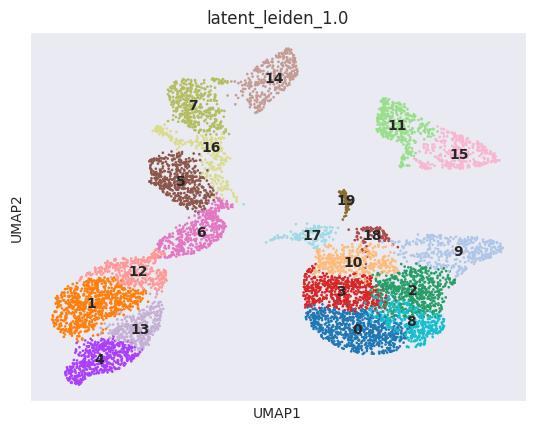

In [46]:
sc.pl.umap(model.adata, color=[latent_cluster_key], wspace=0.15, show=True, legend_loc='on data')

In [47]:
# Save trained model
model_folder_path = f"{workdir}/model"
os.makedirs(model_folder_path, exist_ok=True)

del model.adata.obsm['feat']
model.save(dir_path=model_folder_path,
           overwrite=True,
           save_adata=True,
           adata_file_name="adata_ref.h5ad")

Pickle failed with error: Can't pickle local object 'WeakSet.__init__.<locals>._remove', switching to dill...
Model saved successfully using dill at /data2/zhouwg_data/project/Garfield_benchmark/results/Vertical/RNA_ATAC/8_pbmc_unsorted_10k/model/attr.pkl


In [48]:
# 获取潜在表示
import numpy as np

latent = model.adata.obsm['garfield_latent'].copy()
np.savetxt(os.path.join(workdir, "Garfield.csv"), latent, delimiter=',')

### 数据集6_pbmc_granulocyte_sorted_10x

In [1]:
import os
os.chdir('/data2/zhouwg_data/project/Garfield')
os.getcwd()

'/data2/zhouwg_data/project/Garfield'

In [2]:
# load packages
import os
import warnings
import Garfield as gf
import scanpy as sc
from mudata import MuData
warnings.simplefilter(action="ignore", category=FutureWarning)
warnings.simplefilter(action='ignore', category=UserWarning)

gf.__version__

/home/zhouweige/anaconda3/envs/env_gf_test/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


'0.3.8'

In [6]:
import pandas as pd
from scipy import io
from tqdm import tqdm

def check_file_exists(file_path):
    """Check if the file or directory exists and raise an error if not."""
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"The file or directory {file_path} does not exist.")

def read_rna_data(rna_dir):
    """Read RNA data including barcodes, features, and matrix from the specified directory."""
    rna_barcodes = pd.read_csv(f'{rna_dir}/barcodes.tsv', header=None, sep='\t', dtype=str)
    rna_features = pd.read_csv(f'{rna_dir}/features.tsv', header=None, sep='\t', dtype=str)
    rna_matrix = io.mmread(f'{rna_dir}/matrix.mtx').T.tocsr()

    rna = sc.AnnData(X=rna_matrix)
    rna.var['gene_symbols'] = rna_features.iloc[:, 0].values
    rna.obs['barcodes'] = rna_barcodes.iloc[:, 0].values
    rna.var_names = rna.var['gene_symbols']  # Set feature names
    rna.obs_names = rna.obs['barcodes']  # Set barcode names
    return rna

def read_atac_data(atac_dir):
    """Read ATAC data from the specified CSV file and return it as an AnnData object."""
    atac_barcodes = pd.read_csv(f'{atac_dir}/barcodes.tsv', header=None, sep='\t', dtype=str)
    atac_features = pd.read_csv(f'{atac_dir}/features.tsv', header=None, sep='\t', dtype=str)
    atac_matrix = io.mmread(f'{atac_dir}/matrix.mtx').T.tocsr()

    atac = sc.AnnData(X=atac_matrix)
    atac.var['gene_symbols'] = atac_features.iloc[:, 0].values
    atac.obs['barcodes'] = atac_barcodes.iloc[:, 0].values
    atac.var_names = atac.var['gene_symbols']  # Set feature names
    atac.obs_names = atac.obs['barcodes']  # Set barcode names
    return atac

def read_metadata(metadata_file):
    """Read metadata from a CSV file and return it as a DataFrame."""
    return pd.read_csv(metadata_file, index_col=0)

def read_multiomics_data(rna_dir, atac_dir, metadata_file):
    """
    Reads and processes RNA and ADT data, adding metadata to both.

    Parameters:
        rna_dir (str): Path to the directory containing RNA matrix, barcodes, and features.
        atac_file (str): Path to the CSV file containing ATAC data.
        metadata_file (str): Path to the CSV file containing metadata.

    Returns:
        dict: A dictionary with keys "rna" and "adt" containing the corresponding AnnData objects.
    """
    # Ensure all paths exist
    check_file_exists(rna_dir)
    check_file_exists(atac_dir)
    check_file_exists(metadata_file)

    # Use progress feedback to track steps
    with tqdm(total=3, desc="Reading multiomics data") as pbar:
        # Read RNA data
        rna = read_rna_data(rna_dir)
        pbar.update(1)

        # Read ADT data
        atac = read_atac_data(atac_dir)
        pbar.update(1)

        # Read metadata
        metadata = read_metadata(metadata_file)
        pbar.update(1)

    # Add metadata to RNA and ADT objects
    rna.obs = rna.obs.join(metadata, how="left")  # Ensure all metadata entries align
    atac.obs = atac.obs.join(metadata, how="left")

    return {"rna": rna, "atac": atac}

# Example usage with provided file paths
dataset = '6_pbmc_granulocyte_sorted_10x' #
rna_dir = f'/data2/zhouwg_data/project/Garfield_benchmark/datasets/MultiomicsBenchmark/Raw_data/RNA_ATAC/{dataset}/RNA'
atac_dir = f'/data2/zhouwg_data/project/Garfield_benchmark/datasets/MultiomicsBenchmark/Raw_data/RNA_ATAC/{dataset}/ATAC'
metadata_file = f'/data2/zhouwg_data/project/Garfield_benchmark/datasets/MultiomicsBenchmark/Raw_data/RNA_ATAC/{dataset}/meta_data.csv'

# Read the data
data = read_multiomics_data(rna_dir, atac_dir, metadata_file)

# Access RNA and ADT data separately
rna = data["rna"].copy()
atac = data["atac"].copy()
rna.layers['counts'] = rna.X.copy()
atac.layers['counts'] = atac.X.copy()

Reading multiomics data: 100%|██████████| 3/3 [00:08<00:00,  2.89s/it]


In [7]:
## load data
# rna.X = rna.X.toarray().astype(float)
# atac.X = atac.X.toarray().astype(float)
rna.var['feature_types'] = 'RNA'
atac.var['feature_types'] = 'ATAC'

# split each element for gene score calculation
split_data = atac.var_names.str.split('-', expand=True).to_frame(index=False)
split_data.index = atac.var_names
split_data.columns = ['chr', 'start', 'end']
atac.var[['chr', 'start', 'end']] = split_data

mdata = MuData({"rna": rna, "atac": atac})
mdata

MuData object with n_obs × n_vars = 10137 × 176221
  var:	'gene_symbols', 'feature_types'
  2 modalities
    rna:	10137 x 36601
      obs:	'barcodes', 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'nCount_ATAC', 'nFeature_ATAC', 'TSS.enrichment', 'TSS.percentile', 'nucleosome_signal', 'nucleosome_percentile', 'fragments', 'FRiP', 'blacklist_fraction', 'percent.mt', 'percent.ribo', 'ATAC_snn_res.0.8', 'seurat_clusters', 'nCount_SCT', 'nFeature_SCT', 'SCT_snn_res.0.8', 'predicted.id', 'celltype', 'SCT.weight', 'ATAC.weight', 'wsnn_res.0.8', 'nCount_aRNA', 'nFeature_aRNA', 'aRNA_snn_res.0.8'
      var:	'gene_symbols', 'feature_types'
      layers:	'counts'
    atac:	10137 x 139620
      obs:	'barcodes', 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'nCount_ATAC', 'nFeature_ATAC', 'TSS.enrichment', 'TSS.percentile', 'nucleosome_signal', 'nucleosome_percentile', 'fragments', 'FRiP', 'blacklist_fraction', 'percent.mt', 'percent.ribo', 'ATAC_snn_res.0.8', 'seurat_clusters', 'nCount_SCT', 'nFeature_SCT', 'SCT_snn_res.0.8', 'predicted.id', 'celltype', 'SCT.weight', 'ATAC.weight', 'wsnn_res.0.8', 'nCount_aRNA', 'nFeature_aRNA', 'aRNA_snn_res.0.8'
      var:	'gene_symbols', 'feature_types', 'chr', 'start', 'end'
      layers:	'counts'

In [8]:
# 定义genome类型
human_datasets = ["5_human_brain_10x", "6_pbmc_granulocyte_sorted_10x", "7_human_pbmc_10x",
                  "8_pbmc_unsorted_10k", "9_pbmc_unsorted_3k"]
mouse_datasets = ["1_ShareSeq_Skin", "2_brain_ShareSeq", "3_brain_SNARE","4_brain_ISSAAC_seq","10_GSE201402_down"]

if dataset in human_datasets:
    genome = 'hg38'
else:
    genome = 'mm10'

In [9]:
# set workdir
workdir = f'/data2/zhouwg_data/project/Garfield_benchmark/results/Vertical/RNA_ATAC/{dataset}'
gf.settings.set_workdir(workdir)

### modify parameter
user_config = dict(
    ## Input options
    adata_list=mdata,
    profile='multi-modal',   # if it is 'ATAC' or 'ADT', please adjust it.
    data_type='Paired',
    sub_data_type=['rna', 'atac'],
    sample_col=None,  # Specify columns for batch, only one batch, so set `None`
    weight=0.8,

    ## Preprocessing options
    genome=genome,
    use_gene_weight=True,
    use_top_pcs=False,
    used_hvg=True,
    min_cells=3,
    min_features=0,
    keep_mt=False,
    target_sum=1e4,
    rna_n_top_features=3000,
    atac_n_top_features=10000, # if data belongs to 'ATAC', please specify it.
    n_components=50,
    n_neighbors=5,
    metric='euclidean',
    svd_solver='arpack',
    # datasets
    used_pca_feat=True,
    adj_key='connectivities',

    # data split parameters
    edge_val_ratio=0.1,
    edge_test_ratio=0.,
    node_val_ratio=0.1,
    node_test_ratio=0.,

    ## Model options
    augment_type='svd',
    svd_q=5,
    use_FCencoder=False,
    conv_type='GATv2Conv', # GAT or GATv2Conv or GCN
    gnn_layer=2,
    hidden_dims=[128, 128],
    bottle_neck_neurons=20,
    cluster_num=20,
    drop_feature_rate=0.2,
    drop_edge_rate=0.2,
    num_heads=3,
    dropout=0.2,
    concat=True,
    used_edge_weight=True,
    used_DSBN=False,
    used_mmd=False,
    # data loader parameters
    num_neighbors=5,
    loaders_n_hops=2,
    edge_batch_size=4096,
    node_batch_size=128, # None
    # loss parameters
    include_edge_recon_loss=True,
    include_gene_expr_recon_loss=True,
    lambda_latent_contrastive_instanceloss=1.0,
    lambda_latent_contrastive_clusterloss=0.5,
    lambda_gene_expr_recon=1., # To make the model more focused on learning expression features, increase this parameter.
    lambda_edge_recon=50., # To make the model more focused on learning Adjacency graph features, increase this parameter.
    lambda_latent_adj_recon_loss=2.0,
    lambda_omics_recon_mmd_loss=3., # If the integration is not strong enough, increase it.
    # train parameters
    n_epochs_no_edge_recon=0,
    learning_rate=0.001,
    weight_decay=1e-05,
    gradient_clipping=5,
    # other parameters
    latent_key='garfield_latent',
    reload_best_model=True,
    use_early_stopping=True,
    early_stopping_kwargs=None,
    monitor=True,
    device_id=1,
    seed=2024,
    verbose=True
)
dict_config = gf.settings.set_gf_params(user_config)

Saving results in: /data2/zhouwg_data/project/Garfield_benchmark/results/Vertical/RNA_ATAC/6_pbmc_granulocyte_sorted_10x


In [10]:
from Garfield.model import Garfield

# Initialize model
model = Garfield(dict_config)

--- DATA LOADING AND PREPROCESSING ---
Gene activity matrix has been calculated, loading cached adata_CG_atac object...
There are 18411 common genes in RNA and ATAC datasets
To start performing cell matching for adjacency matrix of the graph, please wait...
Finding initial pivots...
The first data is split into 2 batches, average batch size is 5068, and max batch size is 5069.
The second data is split into 2 batches, average batch size is 5068, and max batch size is 5069.
Batch to batch correspondence is:
  ['0<->0', '1<->1'].
Now at batch 0<->0...
Now at batch 1<->1...
Init_matching done!
Refining pivots...
Now at batch 0<->0...
Now at batch 1<->1...
Refined_matching done!
Filter_bad_matches on pivots matching...
Begin filtering...
7095/10137 pairs of matched cells remain after the filtering.
Fitting CCA on pivots...
Scoring matched pairs...
Propagating matching...
Now at batch 0<->0...
Now at batch 1<->1...
Done!
Filter_bad_matches on propagated matching...
Begin filtering...
26358/2

In [11]:
# Train model
model.train()


--- INITIALIZING TRAINER ---
Using GPU: 1
Number of training nodes: 9123
Number of validation nodes: 1014
Number of training edges: 74599
Number of validation edges: 8288
Edge batch size: 4096
Node batch size: 128

--- MODEL TRAINING ---
Epoch 1/100 |--------------------| 1.0% val_auroc_score: 0.8533; val_auprc_score: 0.8467; val_best_acc_score: 0.8037; val_best_f1_score: 0.8098; train_kl_reg_loss: 47226.8150; train_edge_recon_loss: 52223.4161; train_gene_expr_recon_loss: 152658.3236; train_lambda_latent_adj_recon_loss: 3118.5904; train_lambda_latent_contrastive_instanceloss: 7.0523; train_lambda_latent_contrastive_clusterloss: 3.6938; train_global_loss: 255237.8853; train_optim_loss: 255237.8853; val_kl_reg_loss: 166.4607; val_edge_recon_loss: 35428.7978; val_gene_expr_recon_loss: 105544.7552; val_lambda_latent_adj_recon_loss: 4439.3031; val_lambda_latent_contrastive_instanceloss: 6.7739; val_lambda_latent_contrastive_clusterloss: 3.5978; val_global_loss: 145589.6823; val_optim_loss:

In [12]:
# Compute latent neighbor graph
latent_key = 'garfield_latent'
sc.pp.neighbors(model.adata,
                use_rep=latent_key,
                key_added=latent_key)
# Compute UMAP embedding
sc.tl.umap(model.adata,
           neighbors_key=latent_key)

In [13]:
model.adata

AnnData object with n_obs × n_vars = 10137 × 13000
    obs: 'rna:barcodes', 'rna:orig.ident', 'rna:nCount_RNA', 'rna:nFeature_RNA', 'rna:nCount_ATAC', 'rna:nFeature_ATAC', 'rna:TSS.enrichment', 'rna:TSS.percentile', 'rna:nucleosome_signal', 'rna:nucleosome_percentile', 'rna:fragments', 'rna:FRiP', 'rna:blacklist_fraction', 'rna:percent.mt', 'rna:percent.ribo', 'rna:ATAC_snn_res.0.8', 'rna:seurat_clusters', 'rna:nCount_SCT', 'rna:nFeature_SCT', 'rna:SCT_snn_res.0.8', 'rna:predicted.id', 'rna:celltype', 'rna:SCT.weight', 'rna:ATAC.weight', 'rna:wsnn_res.0.8', 'rna:nCount_aRNA', 'rna:nFeature_aRNA', 'rna:aRNA_snn_res.0.8', 'rna:n_genes', 'atac:barcodes', 'atac:orig.ident', 'atac:nCount_RNA', 'atac:nFeature_RNA', 'atac:nCount_ATAC', 'atac:nFeature_ATAC', 'atac:TSS.enrichment', 'atac:TSS.percentile', 'atac:nucleosome_signal', 'atac:nucleosome_percentile', 'atac:fragments', 'atac:FRiP', 'atac:blacklist_fraction', 'atac:percent.mt', 'atac:percent.ribo', 'atac:ATAC_snn_res.0.8', 'atac:seurat_c

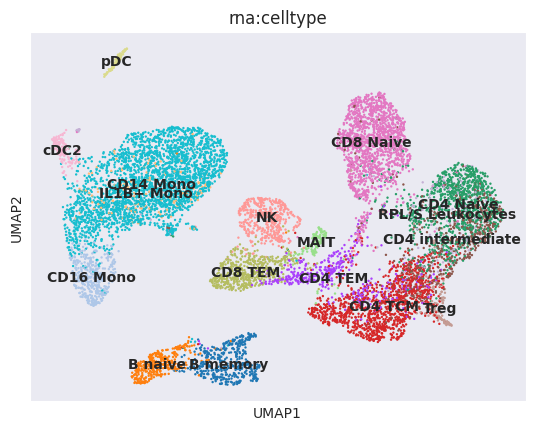

In [14]:
sc.pl.umap(model.adata, color=['rna:celltype'], wspace=0.15, show=True, legend_loc='on data')

In [15]:
# Compute latent Leiden clustering
latent_leiden_resolution = 1.0
latent_cluster_key = f"latent_leiden_{str(latent_leiden_resolution)}"
latent_key = "garfield_latent"

sc.tl.leiden(adata=model.adata,
             resolution=latent_leiden_resolution,
             key_added=latent_cluster_key,
             neighbors_key=latent_key)
len(model.adata.obs[latent_cluster_key].unique())

23

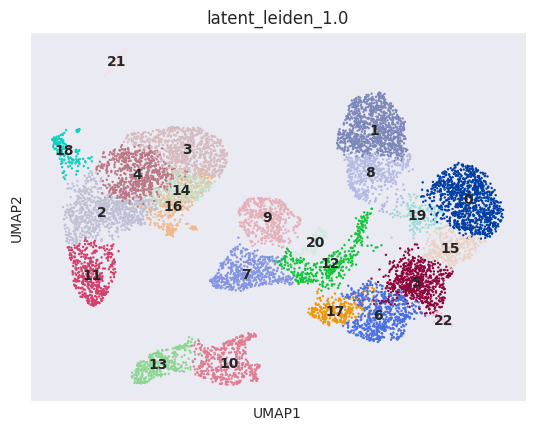

In [16]:
sc.pl.umap(model.adata, color=[latent_cluster_key], wspace=0.15, show=True, legend_loc='on data')

In [17]:
# Save trained model
model_folder_path = f"{workdir}/model"
os.makedirs(model_folder_path, exist_ok=True)

del model.adata.obsm['feat']
model.save(dir_path=model_folder_path,
           overwrite=True,
           save_adata=True,
           adata_file_name="adata_ref.h5ad")

Pickle failed with error: Can't pickle local object 'WeakSet.__init__.<locals>._remove', switching to dill...
Model saved successfully using dill at /data2/zhouwg_data/project/Garfield_benchmark/results/Vertical/RNA_ATAC/6_pbmc_granulocyte_sorted_10x/model/attr.pkl


In [18]:
# 获取潜在表示
import numpy as np

latent = model.adata.obsm['garfield_latent'].copy()
np.savetxt(os.path.join(workdir, "Garfield.csv"), latent, delimiter=',')

### 数据集 5_human_brain_10x with Garfield

In [1]:
import os
os.chdir('/data2/zhouwg_data/project/Garfield')
os.getcwd()

'/data2/zhouwg_data/project/Garfield'

In [2]:
# load packages
import os
import warnings
import Garfield as gf
import scanpy as sc
from mudata import MuData
warnings.simplefilter(action="ignore", category=FutureWarning)
warnings.simplefilter(action='ignore', category=UserWarning)

gf.__version__

/home/zhouweige/anaconda3/envs/env_gf_test/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


'0.3.8'

In [3]:
import pandas as pd
from scipy import io
from tqdm import tqdm

def check_file_exists(file_path):
    """Check if the file or directory exists and raise an error if not."""
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"The file or directory {file_path} does not exist.")

def read_rna_data(rna_dir):
    """Read RNA data including barcodes, features, and matrix from the specified directory."""
    rna_barcodes = pd.read_csv(f'{rna_dir}/barcodes.tsv', header=None, sep='\t', dtype=str)
    rna_features = pd.read_csv(f'{rna_dir}/features.tsv', header=None, sep='\t', dtype=str)
    rna_matrix = io.mmread(f'{rna_dir}/matrix.mtx').T.tocsr()

    rna = sc.AnnData(X=rna_matrix)
    rna.var['gene_symbols'] = rna_features.iloc[:, 0].values
    rna.obs['barcodes'] = rna_barcodes.iloc[:, 0].values
    rna.var_names = rna.var['gene_symbols']  # Set feature names
    rna.obs_names = rna.obs['barcodes']  # Set barcode names
    return rna

def read_atac_data(atac_dir):
    """Read ATAC data from the specified CSV file and return it as an AnnData object."""
    atac_barcodes = pd.read_csv(f'{atac_dir}/barcodes.tsv', header=None, sep='\t', dtype=str)
    atac_features = pd.read_csv(f'{atac_dir}/features.tsv', header=None, sep='\t', dtype=str)
    atac_matrix = io.mmread(f'{atac_dir}/matrix.mtx').T.tocsr()

    atac = sc.AnnData(X=atac_matrix)
    atac.var['gene_symbols'] = atac_features.iloc[:, 0].values
    atac.obs['barcodes'] = atac_barcodes.iloc[:, 0].values
    atac.var_names = atac.var['gene_symbols']  # Set feature names
    atac.obs_names = atac.obs['barcodes']  # Set barcode names
    return atac

def read_metadata(metadata_file):
    """Read metadata from a CSV file and return it as a DataFrame."""
    return pd.read_csv(metadata_file, index_col=0)

def read_multiomics_data(rna_dir, atac_dir, metadata_file):
    """
    Reads and processes RNA and ADT data, adding metadata to both.

    Parameters:
        rna_dir (str): Path to the directory containing RNA matrix, barcodes, and features.
        atac_file (str): Path to the CSV file containing ATAC data.
        metadata_file (str): Path to the CSV file containing metadata.

    Returns:
        dict: A dictionary with keys "rna" and "adt" containing the corresponding AnnData objects.
    """
    # Ensure all paths exist
    check_file_exists(rna_dir)
    check_file_exists(atac_dir)
    check_file_exists(metadata_file)

    # Use progress feedback to track steps
    with tqdm(total=3, desc="Reading multiomics data") as pbar:
        # Read RNA data
        rna = read_rna_data(rna_dir)
        pbar.update(1)

        # Read ADT data
        atac = read_atac_data(atac_dir)
        pbar.update(1)

        # Read metadata
        metadata = read_metadata(metadata_file)
        pbar.update(1)

    # Add metadata to RNA and ADT objects
    rna.obs = rna.obs.join(metadata, how="left")  # Ensure all metadata entries align
    atac.obs = atac.obs.join(metadata, how="left")

    return {"rna": rna, "atac": atac}

# Example usage with provided file paths
dataset = '5_human_brain_10x' #
rna_dir = f'/data2/zhouwg_data/project/Garfield_benchmark/datasets/MultiomicsBenchmark/Raw_data/RNA_ATAC/{dataset}/RNA'
atac_dir = f'/data2/zhouwg_data/project/Garfield_benchmark/datasets/MultiomicsBenchmark/Raw_data/RNA_ATAC/{dataset}/ATAC'
metadata_file = f'/data2/zhouwg_data/project/Garfield_benchmark/datasets/MultiomicsBenchmark/Raw_data/RNA_ATAC/{dataset}/meta_data.csv'

# Read the data
data = read_multiomics_data(rna_dir, atac_dir, metadata_file)

# Access RNA and ADT data separately
rna = data["rna"].copy()
atac = data["atac"].copy()
rna.layers['counts'] = rna.X.copy()
atac.layers['counts'] = atac.X.copy()

Reading multiomics data: 100%|██████████| 3/3 [00:01<00:00,  2.04it/s]


In [4]:
## load data
# rna.X = rna.X.toarray().astype(float)
# atac.X = atac.X.toarray().astype(float)
rna.var['feature_types'] = 'RNA'
atac.var['feature_types'] = 'ATAC'

# split each element for gene score calculation
split_data = atac.var_names.str.split('-', expand=True).to_frame(index=False)
split_data.index = atac.var_names
split_data.columns = ['chr', 'start', 'end']
atac.var[['chr', 'start', 'end']] = split_data

mdata = MuData({"rna": rna, "atac": atac})
mdata

MuData object with n_obs × n_vars = 2855 × 167463
  var:	'gene_symbols', 'feature_types'
  2 modalities
    rna:	2855 x 36601
      obs:	'barcodes', 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'nCount_ATAC', 'nFeature_ATAC', 'TSS.enrichment', 'TSS.percentile', 'nucleosome_signal', 'nucleosome_percentile', 'fragments', 'FRiP', 'blacklist_fraction', 'percent.mt', 'percent.ribo', 'ATAC_snn_res.0.8', 'seurat_clusters', 'RNA_snn_res.0.5', 'predicted.id', 'celltype', 'RNA.weight', 'ATAC.weight', 'wsnn_res.0.8'
      var:	'gene_symbols', 'feature_types'
      layers:	'counts'
    atac:	2855 x 130862
      obs:	'barcodes', 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'nCount_ATAC', 'nFeature_ATAC', 'TSS.enrichment', 'TSS.percentile', 'nucleosome_signal', 'nucleosome_percentile', 'fragments', 'FRiP', 'blacklist_fraction', 'percent.mt', 'percent.ribo', 'ATAC_snn_res.0.8', 'seurat_clusters', 'RNA_snn_res.0.5', 'predicted.id', 'celltype', 'RNA.weight', 'ATAC.weight', 'wsnn_res.0.8'
      var:	'gene_symbols', 'feature_types', 'chr', 'start', 'end'
      layers:	'counts'

In [5]:
# 定义genome类型
human_datasets = ["5_human_brain_10x", "6_pbmc_granulocyte_sorted_10x", "7_human_pbmc_10x",
                  "8_pbmc_unsorted_10k", "9_pbmc_unsorted_3k"]
mouse_datasets = ["1_ShareSeq_Skin", "2_brain_ShareSeq", "3_brain_SNARE","4_brain_ISSAAC_seq","10_GSE201402_down"]

if dataset in human_datasets:
    genome = 'hg38'
else:
    genome = 'mm10'

In [6]:
# set workdir
workdir = f'/data2/zhouwg_data/project/Garfield_benchmark/results/Vertical/RNA_ATAC/{dataset}'
gf.settings.set_workdir(workdir)

### modify parameter
user_config = dict(
    ## Input options
    adata_list=mdata,
    profile='multi-modal',   # if it is 'ATAC' or 'ADT', please adjust it.
    data_type='Paired',
    sub_data_type=['rna', 'atac'],
    sample_col=None,  # Specify columns for batch, only one batch, so set `None`
    weight=0.8,

    ## Preprocessing options
    genome=genome,
    use_gene_weight=True,
    use_top_pcs=False,
    used_hvg=True,
    min_cells=3,
    min_features=0,
    keep_mt=False,
    target_sum=1e4,
    rna_n_top_features=3000,
    atac_n_top_features=10000, # if data belongs to 'ATAC', please specify it.
    n_components=50,
    n_neighbors=5,
    metric='euclidean',
    svd_solver='arpack',
    # datasets
    used_pca_feat=True,
    adj_key='connectivities',

    # data split parameters
    edge_val_ratio=0.1,
    edge_test_ratio=0.,
    node_val_ratio=0.1,
    node_test_ratio=0.,

    ## Model options
    augment_type='svd',
    svd_q=5,
    use_FCencoder=False,
    conv_type='GATv2Conv', # GAT or GATv2Conv or GCN
    gnn_layer=2,
    hidden_dims=[128, 128],
    bottle_neck_neurons=20,
    cluster_num=20,
    drop_feature_rate=0.2,
    drop_edge_rate=0.2,
    num_heads=3,
    dropout=0.2,
    concat=True,
    used_edge_weight=True,
    used_DSBN=False,
    used_mmd=False,
    # data loader parameters
    num_neighbors=5,
    loaders_n_hops=2,
    edge_batch_size=4096,
    node_batch_size=128, # None
    # loss parameters
    include_edge_recon_loss=True,
    include_gene_expr_recon_loss=True,
    lambda_latent_contrastive_instanceloss=1.0,
    lambda_latent_contrastive_clusterloss=0.5,
    lambda_gene_expr_recon=1., # To make the model more focused on learning expression features, increase this parameter.
    lambda_edge_recon=50., # To make the model more focused on learning Adjacency graph features, increase this parameter.
    lambda_latent_adj_recon_loss=2.0,
    lambda_omics_recon_mmd_loss=3., # If the integration is not strong enough, increase it.
    # train parameters
    n_epochs_no_edge_recon=0,
    learning_rate=0.001,
    weight_decay=1e-05,
    gradient_clipping=5,
    # other parameters
    latent_key='garfield_latent',
    reload_best_model=True,
    use_early_stopping=True,
    early_stopping_kwargs=None,
    monitor=True,
    device_id=1,
    seed=2024,
    verbose=True
)
dict_config = gf.settings.set_gf_params(user_config)

Saving results in: /data2/zhouwg_data/project/Garfield_benchmark/results/Vertical/RNA_ATAC/5_human_brain_10x


In [7]:
from Garfield.model import Garfield

# Initialize model
model = Garfield(dict_config)

--- DATA LOADING AND PREPROCESSING ---
Gene activity matrix has been calculated, loading cached adata_CG_atac object...
There are 19354 common genes in RNA and ATAC datasets
To start performing cell matching for adjacency matrix of the graph, please wait...
Finding initial pivots...
The first data is split into 1 batches, average batch size is 2855, and max batch size is 2855.
The second data is split into 1 batches, average batch size is 2855, and max batch size is 2855.
Batch to batch correspondence is:
  ['0<->0'].
Now at batch 0<->0...
Init_matching done!
Refining pivots...
Now at batch 0<->0...
Refined_matching done!
Filter_bad_matches on pivots matching...
Begin filtering...
1998/2855 pairs of matched cells remain after the filtering.
Fitting CCA on pivots...
Scoring matched pairs...
Propagating matching...
Now at batch 0<->0...
Done!
Filter_bad_matches on propagated matching...
Begin filtering...
1714/1714 pairs of matched cells remain after the filtering.
Fitting CCA on pivots.

In [8]:
# Train model
model.train()


--- INITIALIZING TRAINER ---
Using GPU: 1
Number of training nodes: 2569
Number of validation nodes: 286
Number of training edges: 19111
Number of validation edges: 2123
Edge batch size: 4096
Node batch size: 128

--- MODEL TRAINING ---
Epoch 1/100 |--------------------| 1.0% val_auroc_score: 0.8513; val_auprc_score: 0.8413; val_best_acc_score: 0.7760; val_best_f1_score: 0.7903; train_kl_reg_loss: 857414.8492; train_edge_recon_loss: 53006.6125; train_gene_expr_recon_loss: 628680551.8000; train_lambda_latent_adj_recon_loss: 2621.2963; train_lambda_latent_contrastive_instanceloss: 7.1150; train_lambda_latent_contrastive_clusterloss: 3.7413; train_global_loss: 629593591.2000; train_optim_loss: 629593591.2000; val_kl_reg_loss: 90.0856; val_edge_recon_loss: 30502.3184; val_gene_expr_recon_loss: 289523.1562; val_lambda_latent_adj_recon_loss: 2539.1892; val_lambda_latent_contrastive_instanceloss: 6.9154; val_lambda_latent_contrastive_clusterloss: 3.6550; val_global_loss: 322665.3125; val_opt

In [9]:
# Compute latent neighbor graph
latent_key = 'garfield_latent'
sc.pp.neighbors(model.adata,
                use_rep=latent_key,
                key_added=latent_key)
# Compute UMAP embedding
sc.tl.umap(model.adata,
           neighbors_key=latent_key)

In [10]:
model.adata

AnnData object with n_obs × n_vars = 2855 × 13000
    obs: 'rna:barcodes', 'rna:orig.ident', 'rna:nCount_RNA', 'rna:nFeature_RNA', 'rna:nCount_ATAC', 'rna:nFeature_ATAC', 'rna:TSS.enrichment', 'rna:TSS.percentile', 'rna:nucleosome_signal', 'rna:nucleosome_percentile', 'rna:fragments', 'rna:FRiP', 'rna:blacklist_fraction', 'rna:percent.mt', 'rna:percent.ribo', 'rna:ATAC_snn_res.0.8', 'rna:seurat_clusters', 'rna:RNA_snn_res.0.5', 'rna:predicted.id', 'rna:celltype', 'rna:RNA.weight', 'rna:ATAC.weight', 'rna:wsnn_res.0.8', 'rna:n_genes', 'atac:barcodes', 'atac:orig.ident', 'atac:nCount_RNA', 'atac:nFeature_RNA', 'atac:nCount_ATAC', 'atac:nFeature_ATAC', 'atac:TSS.enrichment', 'atac:TSS.percentile', 'atac:nucleosome_signal', 'atac:nucleosome_percentile', 'atac:fragments', 'atac:FRiP', 'atac:blacklist_fraction', 'atac:percent.mt', 'atac:percent.ribo', 'atac:ATAC_snn_res.0.8', 'atac:seurat_clusters', 'atac:RNA_snn_res.0.5', 'atac:predicted.id', 'atac:celltype', 'atac:RNA.weight', 'atac:ATAC.w

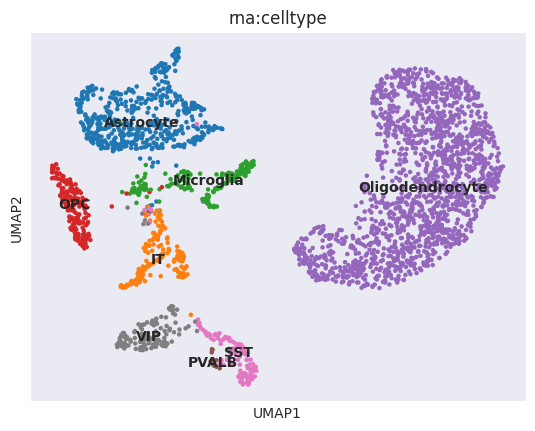

In [11]:
sc.pl.umap(model.adata, color=['rna:celltype'], wspace=0.15, show=True, legend_loc='on data')

In [12]:
# Compute latent Leiden clustering
latent_leiden_resolution = 1.0
latent_cluster_key = f"latent_leiden_{str(latent_leiden_resolution)}"
latent_key = "garfield_latent"

sc.tl.leiden(adata=model.adata,
             resolution=latent_leiden_resolution,
             key_added=latent_cluster_key,
             neighbors_key=latent_key)
len(model.adata.obs[latent_cluster_key].unique())

19

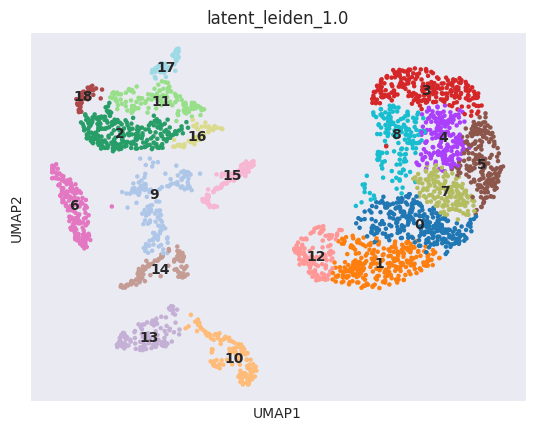

In [13]:
sc.pl.umap(model.adata, color=[latent_cluster_key], wspace=0.15, show=True, legend_loc='on data')

In [14]:
# Save trained model
model_folder_path = f"{workdir}/model"
os.makedirs(model_folder_path, exist_ok=True)

del model.adata.obsm['feat']
model.save(dir_path=model_folder_path,
           overwrite=True,
           save_adata=True,
           adata_file_name="adata_ref.h5ad")

Pickle failed with error: Can't pickle local object 'WeakSet.__init__.<locals>._remove', switching to dill...
Model saved successfully using dill at /data2/zhouwg_data/project/Garfield_benchmark/results/Vertical/RNA_ATAC/5_human_brain_10x/model/attr.pkl


In [15]:
# 获取潜在表示
import numpy as np

latent = model.adata.obsm['garfield_latent'].copy()
np.savetxt(os.path.join(workdir, "Garfield.csv"), latent, delimiter=',')

## MOFA model

In [3]:
# Example usage with provided file paths
dataset = '1_ShareSeq_Skin'
rna_dir = f'/data2/zhouwg_data/project/Garfield_benchmark/datasets/MultiomicsBenchmark/Raw_data/RNA_ATAC/{dataset}/RNA'
atac_dir = f'/data2/zhouwg_data/project/Garfield_benchmark/datasets/MultiomicsBenchmark/Raw_data/RNA_ATAC/{dataset}/ATAC'
metadata_file = f'/data2/zhouwg_data/project/Garfield_benchmark/datasets/MultiomicsBenchmark/Raw_data/RNA_ATAC/{dataset}/meta_data.csv'
res_dir = f'/data2/zhouwg_data/project/Garfield_benchmark/results/Vertical/RNA_ATAC/{dataset}'
# 判断res_dir是否存在，不存在新建
if not os.path.exists(res_dir):
    os.makedirs(res_dir)

# Read the data
data = read_multiomics_data(rna_dir, atac_dir, metadata_file)

# Access RNA and ADT data separately
adata_RNA = data["rna"]
adata_ATAC = data["atac"]
adata_RNA.var_names_make_unique()
adata_RNA.layers['counts'] = adata_RNA.X.copy()
adata_ATAC.layers['counts'] = adata_ATAC.X.copy()

sc.pp.filter_cells(adata_RNA, min_genes=10)
sc.pp.filter_genes(adata_RNA, min_cells=20)
sc.pp.filter_cells(adata_ATAC, min_genes=10)
sc.pp.filter_genes(adata_ATAC, min_cells=1)

sc.pp.highly_variable_genes(
    adata_ATAC,
    flavor="seurat_v3",
    n_top_genes=10000,
    subset=False
)

sc.pp.highly_variable_genes(
    adata_RNA,
    flavor="seurat_v3",
    n_top_genes=3000,
    subset=False
)
# adata_RNA.layers["counts"] = adata_RNA.X.copy()
sc.pp.normalize_total(adata_RNA, target_sum=1e4)
sc.pp.log1p(adata_RNA)
adata_RNA = adata_RNA[:, adata_RNA.var.highly_variable].copy()
# rna.raw = rna
# adata_RNA.layers["lognorm"] = adata_RNA.X.copy()

# adata_ATAC.layers["counts"] = adata_ATAC.X.copy()
sc.pp.normalize_total(adata_ATAC, target_sum=1e4)
sc.pp.log1p(adata_ATAC)
adata_ATAC = adata_ATAC[:, adata_ATAC.var.highly_variable].copy()
# adata_ATAC.layers["lognorm"] = adata_ATAC.X.copy()

mdata = MuData({'rna': adata_RNA, 'atac': adata_ATAC})
del adata_RNA, adata_ATAC, data

start_time = time.time() #From now on time
mu.tl.mofa(mdata, gpu_mode=False, outfile=os.path.join(res_dir, "MOFA.hdf5"),use_var=None)

# mdata.write("mudata_GPU.h5mu")
# mdata.obsm['X_mofa'].shape
# mdata_CPU = mu.read("./mudata_CUP.h5mu")
np.savetxt(os.path.join(res_dir, "MOFA.csv"), mdata.obsm['X_mofa'], delimiter=',')
end_time = time.time()

execution_time = end_time - start_time
print(f"running time:{execution_time} s")

Reading multiomics data:   0%|          | 0/3 [00:00<?, ?it/s]/tmp/ipykernel_2161003/2787740447.py:16: FutureWarning: X.dtype being converted to np.float32 from int64. In the next version of anndata (0.9) conversion will not be automatic. Pass dtype explicitly to avoid this warning. Pass `AnnData(X, dtype=X.dtype, ...)` to get the future behavour.
  rna = sc.AnnData(X=rna_matrix)
Reading multiomics data:  33%|███▎      | 1/3 [00:29<00:58, 29.01s/it]/tmp/ipykernel_2161003/2787740447.py:29: FutureWarning: X.dtype being converted to np.float32 from int64. In the next version of anndata (0.9) conversion will not be automatic. Pass dtype explicitly to avoid this warning. Pass `AnnData(X, dtype=X.dtype, ...)` to get the future behavour.
  atac = sc.AnnData(X=atac_matrix)
Reading multiomics data: 100%|██████████| 3/3 [03:36<00:00, 72.32s/it] 



        #########################################################
        ###           __  __  ____  ______                    ### 
        ###          |  \/  |/ __ \|  ____/\    _             ### 
        ###          | \  / | |  | | |__ /  \ _| |_           ### 
        ###          | |\/| | |  | |  __/ /\ \_   _|          ###
        ###          | |  | | |__| | | / ____ \|_|            ###
        ###          |_|  |_|\____/|_|/_/    \_\              ###
        ###                                                   ### 
        ######################################################### 
       
 
        
Loaded view='rna' group='group1' with N=34774 samples and D=3000 features...
Loaded view='atac' group='group1' with N=34774 samples and D=10000 features...


Model options:
- Automatic Relevance Determination prior on the factors: True
- Automatic Relevance Determination prior on the weights: True
- Spike-and-slab prior on the factors: False
- Spike-and-slab prior on the weights

## RunMultiVI model

In [ ]:
from scipy.io import mmread
from scipy.sparse import csr_matrix
import anndata as ad
import pandas as pd
import scvi
import numpy as np
import scanpy as sc
scvi.settings.seed = 420
import os, sys, time

# Example usage with provided file paths
dataset = '1_ShareSeq_Skin'
rna_dir = f'/data2/zhouwg_data/project/Garfield_benchmark/datasets/MultiomicsBenchmark/Raw_data/RNA_ATAC/{dataset}/RNA'
atac_dir = f'/data2/zhouwg_data/project/Garfield_benchmark/datasets/MultiomicsBenchmark/Raw_data/RNA_ATAC/{dataset}/ATAC'
metadata_file = f'/data2/zhouwg_data/project/Garfield_benchmark/datasets/MultiomicsBenchmark/Raw_data/RNA_ATAC/{dataset}/meta_data.csv'
res_dir = f'/data2/zhouwg_data/project/Garfield_benchmark/results/Vertical/RNA_ATAC/{dataset}'
# 判断res_dir是否存在，不存在新建
if not os.path.exists(res_dir):
    os.makedirs(res_dir)

# Read the data
data = read_multiomics_data(rna_dir, atac_dir, metadata_file)

# Access RNA and ADT data separately
adata_RNA = data["rna"]
adata_ATAC = data["atac"]
adata_RNA.var_names_make_unique()
adata_RNA.layers['counts'] = adata_RNA.X.copy()
adata_ATAC.layers['counts'] = adata_ATAC.X.copy()

sc.pp.filter_cells(adata_RNA, min_genes=10)
sc.pp.filter_genes(adata_RNA, min_cells=20)
sc.pp.filter_cells(adata_ATAC, min_genes=10)
sc.pp.filter_genes(adata_ATAC, min_cells=1)

sc.pp.highly_variable_genes(
    adata_ATAC,
    flavor="seurat_v3",
    n_top_genes=10000,
    subset=True
)

sc.pp.highly_variable_genes(
    adata_RNA,
    flavor="seurat_v3",
    n_top_genes=3000,
    subset=True
)

adata_paired = ad.concat([adata_RNA, adata_ATAC], merge = "same",axis=1) 
adata_paired.var['modality']=['Gene Expression']*adata_RNA.shape[1]+['Peaks']*adata_ATAC.shape[1]

start_time = time.time() #From now on time
# We can now use the organizing method from scvi to concatenate these anndata
adata_mvi = scvi.data.organize_multiome_anndatas(adata_paired)
del adata_paired
# adata_mvi.obs
adata_mvi = adata_mvi[:, adata_mvi.var["modality"].argsort()].copy()
# adata_mvi.var

scvi.model.MULTIVI.setup_anndata(adata_mvi, batch_key="modality")
model = scvi.model.MULTIVI(
    adata_mvi,
    n_genes=(adata_mvi.var["modality"] == "Gene Expression").sum(),
    n_regions=(adata_mvi.var["modality"] == "Peaks").sum(),
)
model.view_anndata_setup()
model.train()

latent = model.get_latent_representation()
np.savetxt(os.path.join(res_dir, "MultiVI.csv"), latent, delimiter=',')
end_time = time.time()

execution_time = end_time - start_time
print(f"running time:{execution_time} s")

### run RunMultigrate

In [3]:
import scarches as sca
import scanpy as sc
import anndata as ad
import pandas as pd
import numpy as np
from scipy.io import mmread
from scipy.sparse import csr_matrix
import muon
import gdown
import json
import time
import os
import sys
from multigrate.data import organize_multiome_anndatas
from multigrate.model import MultiVAE

import warnings
warnings.filterwarnings("ignore")

# Example usage with provided file paths
dataset = '1_ShareSeq_Skin'
rna_dir = f'/data2/zhouwg_data/project/Garfield_benchmark/datasets/MultiomicsBenchmark/Raw_data/RNA_ATAC/{dataset}/RNA'
atac_dir = f'/data2/zhouwg_data/project/Garfield_benchmark/datasets/MultiomicsBenchmark/Raw_data/RNA_ATAC/{dataset}/ATAC'
metadata_file = f'/data2/zhouwg_data/project/Garfield_benchmark/datasets/MultiomicsBenchmark/Raw_data/RNA_ATAC/{dataset}/meta_data.csv'
res_dir = f'/data2/zhouwg_data/project/Garfield_benchmark/results/Vertical/RNA_ATAC/{dataset}'
# 判断res_dir是否存在，不存在新建
if not os.path.exists(res_dir):
    os.makedirs(res_dir)

# Read the data
data = read_multiomics_data(rna_dir, atac_dir, metadata_file)

# Access RNA and ADT data separately
adata_RNA = data["rna"]
adata_ATAC = data["atac"]
adata_RNA.var_names_make_unique()
adata_ATAC.var_names_make_unique()
adata_RNA.layers['counts'] = adata_RNA.X.copy()
adata_ATAC.layers['counts'] = adata_ATAC.X.copy()

# normalize and log the RNA data
sc.pp.normalize_total(adata_RNA)
sc.pp.log1p(adata_RNA)
sc.pp.highly_variable_genes(
    adata_RNA,
    flavor="seurat_v3",
    n_top_genes=3000,
    subset=False
)
adata_RNA = adata_RNA[:, adata_RNA.var.highly_variable].copy()

# normalize and log the ATAC data
sc.pp.normalize_total(adata_ATAC, target_sum=1e4)
sc.pp.log1p(adata_ATAC)
adata_ATAC.layers['log-norm'] = adata_ATAC.X.copy()
sc.pp.highly_variable_genes(
    adata_ATAC,
    flavor="seurat_v3",
    n_top_genes=10000,
    subset=False
)
adata_ATAC = adata_ATAC[:, adata_ATAC.var.highly_variable].copy()

start_time = time.time()
adata = organize_multiome_anndatas( # sca.models.
    adatas = [[adata_RNA], [adata_ATAC]],    # a list of anndata objects per modality, RNA-seq always goes first
    layers = [['counts'], ['log-norm']], # if need to use data from .layers, if None use .X
)

MultiVAE.setup_anndata(
    adata,
    rna_indices_end=3000,
)
model = MultiVAE(
    adata,
    losses=['nb', 'mse'],
    loss_coefs={'kl': 1e-1,
               'integ': 3000,
               },
)
model.train()
model.get_latent_representation()
latent = adata.obsm['latent'].copy()
np.savetxt(os.path.join(res_dir, "Multigrate.csv"), latent, delimiter=',')

end_time = time.time()
execution_time = end_time - start_time
print(f"running time:{execution_time} s")

Reading multiomics data: 100%|██████████| 3/3 [00:05<00:00,  1.77s/it]
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:IPU available: False, using: 0 IPUs
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.utilities.rank_zero:You are using a CUDA device ('NVIDIA A800 80GB PCIe') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3]


Epoch 134/200:  67%|██████▋   | 134/200 [08:59<04:25,  4.02s/it, loss=254, v_num=1]
Monitored metric reconstruction_loss_validation did not improve in the last 50 records. Best score: 252.470. Signaling Trainer to stop.
running time:549.3169586658478 s
